In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
sns.set_style('whitegrid')

csv_scored = '../results/sentiment_analysis/yelp_academic_dataset_review_scored.csv'
topics_dir     = '../results/topic_modeling'
visualization_dir       = '../results/topic_modeling/visualizations'

categories = ['burgers', 'fast_food', 'mexican', 'pubs', 'steakhouses']

topic_files = {cat: os.path.join(topics_dir, f'yelp_topics_{cat}.csv') for cat in categories}

sentiment_cols = ['review_id', 'stars', 'vader_score', 'afinn_score']

topic_models = {
    'bertopic': 'bertopic_dominant_topic',
    'lda':      'lda_dominant_topic',
}

top_n = 10  # top-N tópicos por volumen de reviews

In [2]:
def cargar_datos_sentimiento_topicos(categories, topic_files, csv_scored, sentiment_cols):
    """
    Carga los CSVs de tópicos y de sentimiento y los une por review_id.
    """
    sent_lazy = pl.scan_csv(csv_scored).select(sentiment_cols)

    category_dfs = {}
    for cat in categories:
        topic_lazy = pl.scan_csv(topic_files[cat])
        joined = (
            topic_lazy
            .join(sent_lazy, on='review_id', how='left', suffix='_sent')
            .select([
                'review_id',
                pl.col('stars'),
                'vader_score',
                'afinn_score',
                'lda_dominant_topic',
                'bertopic_dominant_topic',
            ])
            .drop_nulls(subset=['vader_score', 'afinn_score'])
            .collect()
        )
        category_dfs[cat] = joined
        print(f'{cat}: {joined.shape[0]:,} reviews')

    return category_dfs

category_dfs = cargar_datos_sentimiento_topicos(categories, topic_files, csv_scored, sentiment_cols)
print('Carga completada.')

burgers: 445,895 reviews
fast_food: 233,008 reviews
mexican: 432,248 reviews
pubs: 218,891 reviews
steakhouses: 240,040 reviews
Carga completada.


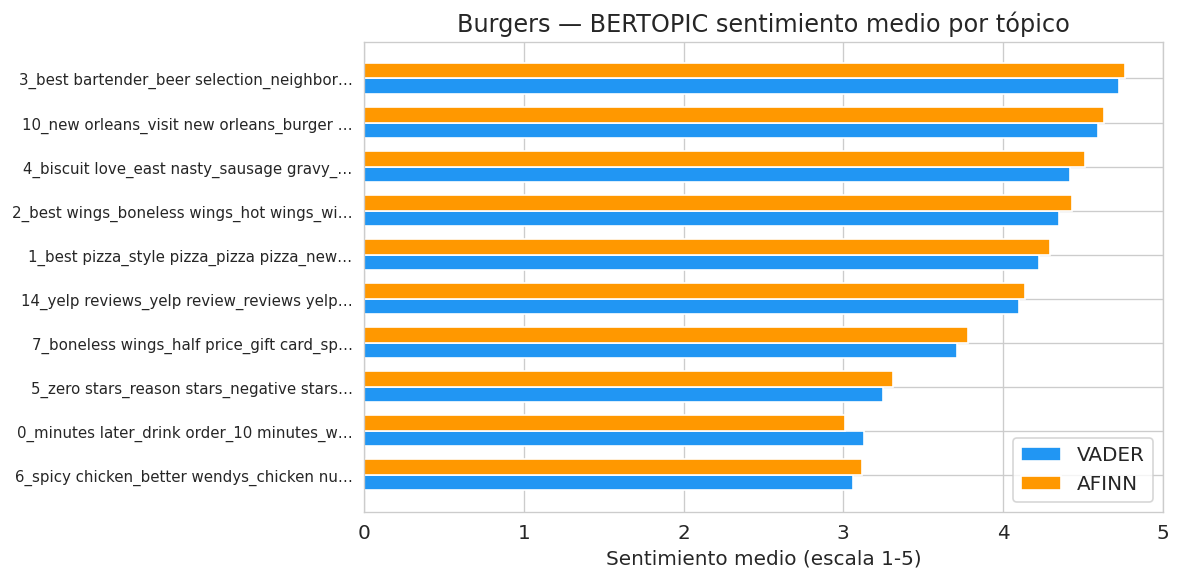


Análisis de polaridad: Burgers - BERTOPIC
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'6_spicy chicken_better wendys_chicken nu…' (VADER medio: 3.062 | Menciones: 1964)
'0_minutes later_drink order_10 minutes_w…' (VADER medio: 3.131 | Menciones: 4888)
'5_zero stars_reason stars_negative stars…' (VADER medio: 3.247 | Menciones: 2037)

Tópicos más positivos):
'3_best bartender_beer selection_neighbor…' (VADER medio: 4.726 | Menciones: 3311)
'10_new orleans_visit new orleans_burger …' (VADER medio: 4.593 | Menciones: 1767)
'4_biscuit love_east nasty_sausage gravy_…' (VADER medio: 4.419 | Menciones: 1984)
---------------------------------------------------------------------------


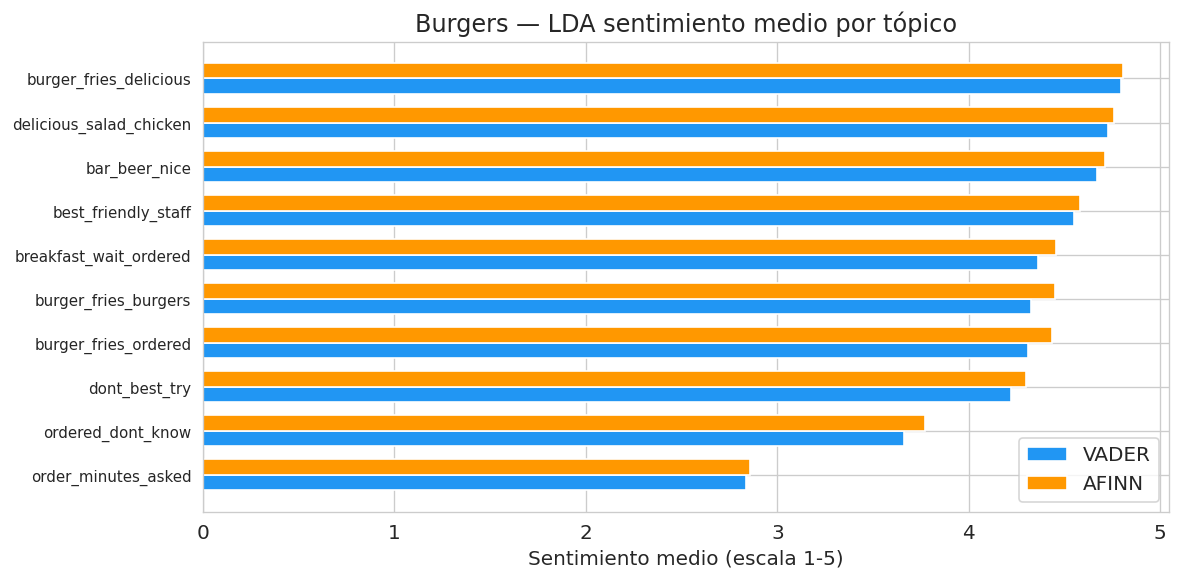


Análisis de polaridad: Burgers - LDA
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'order_minutes_asked' (VADER medio: 2.837 | Menciones: 87977)
'ordered_dont_know' (VADER medio: 3.659 | Menciones: 20013)
'dont_best_try' (VADER medio: 4.221 | Menciones: 24837)

Tópicos más positivos):
'burger_fries_delicious' (VADER medio: 4.792 | Menciones: 64785)
'delicious_salad_chicken' (VADER medio: 4.729 | Menciones: 40148)
'bar_beer_nice' (VADER medio: 4.668 | Menciones: 58833)
---------------------------------------------------------------------------


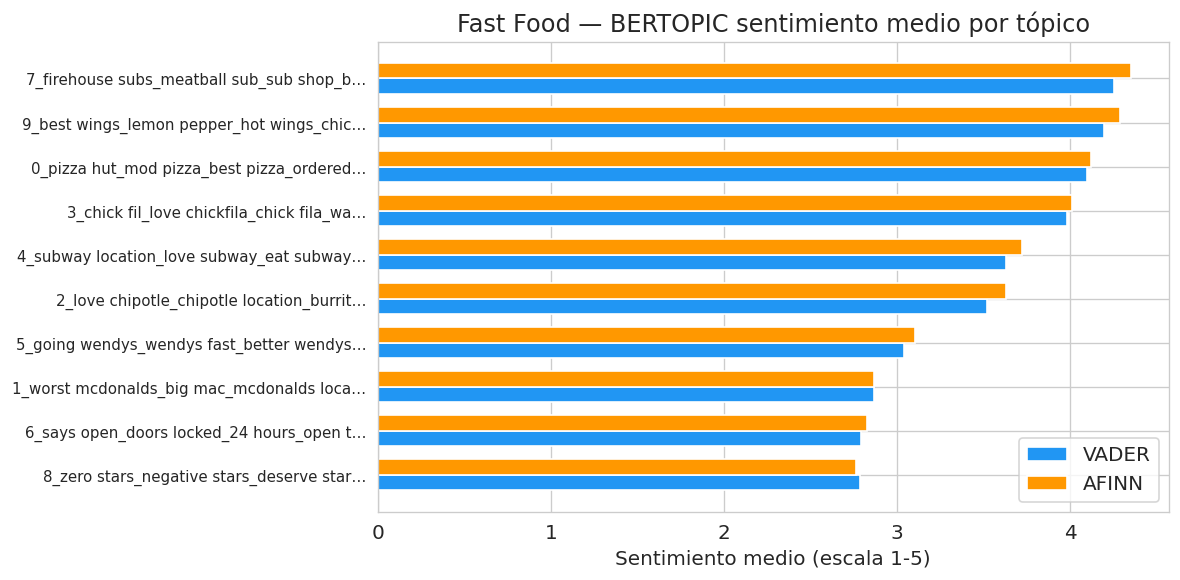


Análisis de polaridad: Fast Food - BERTOPIC
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'8_zero stars_negative stars_deserve star…' (VADER medio: 2.783 | Menciones: 1583)
'6_says open_doors locked_24 hours_open t…' (VADER medio: 2.789 | Menciones: 1998)
'1_worst mcdonalds_big mac_mcdonalds loca…' (VADER medio: 2.868 | Menciones: 5874)

Tópicos más positivos):
'7_firehouse subs_meatball sub_sub shop_b…' (VADER medio: 4.250 | Menciones: 1511)
'9_best wings_lemon pepper_hot wings_chic…' (VADER medio: 4.195 | Menciones: 1625)
'0_pizza hut_mod pizza_best pizza_ordered…' (VADER medio: 4.093 | Menciones: 11729)
---------------------------------------------------------------------------


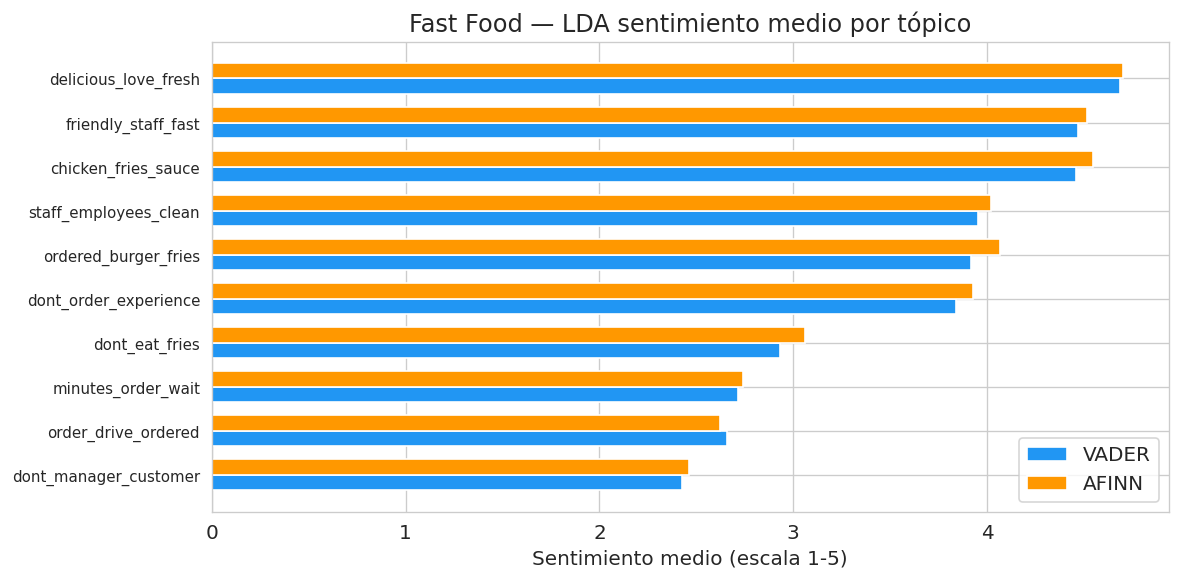


Análisis de polaridad: Fast Food - LDA
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'dont_manager_customer' (VADER medio: 2.424 | Menciones: 17201)
'order_drive_ordered' (VADER medio: 2.657 | Menciones: 25739)
'minutes_order_wait' (VADER medio: 2.715 | Menciones: 26796)

Tópicos más positivos):
'delicious_love_fresh' (VADER medio: 4.686 | Menciones: 33274)
'friendly_staff_fast' (VADER medio: 4.471 | Menciones: 32199)
'chicken_fries_sauce' (VADER medio: 4.456 | Menciones: 38312)
---------------------------------------------------------------------------


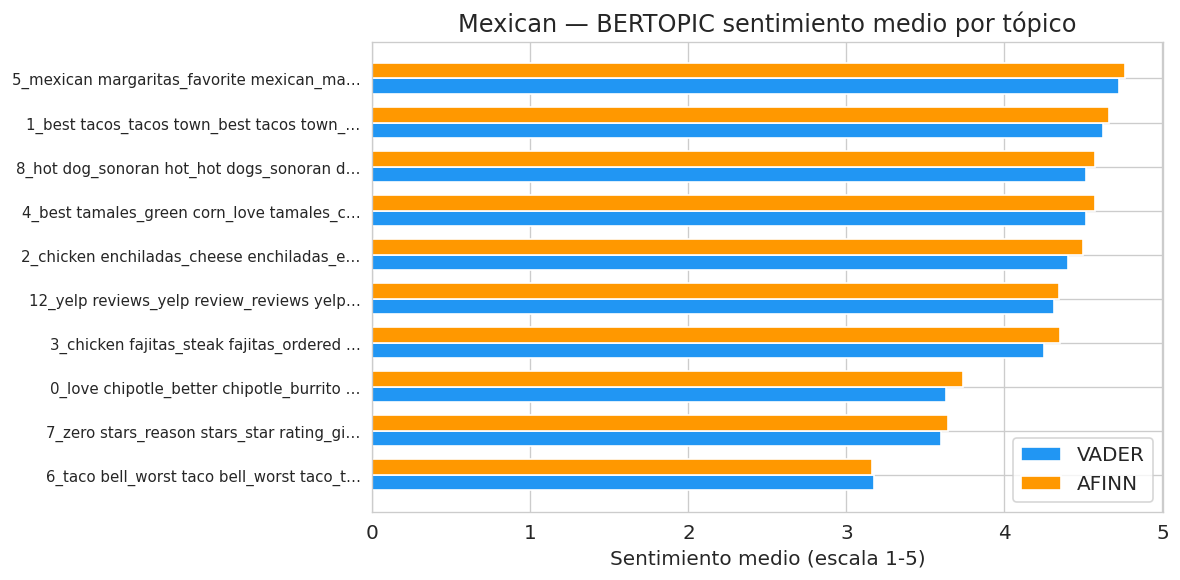


Análisis de polaridad: Mexican - BERTOPIC
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'6_taco bell_worst taco bell_worst taco_t…' (VADER medio: 3.172 | Menciones: 1911)
'7_zero stars_reason stars_star rating_gi…' (VADER medio: 3.599 | Menciones: 1882)
'0_love chipotle_better chipotle_burrito …' (VADER medio: 3.628 | Menciones: 5058)

Tópicos más positivos):
'5_mexican margaritas_favorite mexican_ma…' (VADER medio: 4.723 | Menciones: 2601)
'1_best tacos_tacos town_best tacos town_…' (VADER medio: 4.621 | Menciones: 3943)
'8_hot dog_sonoran hot_hot dogs_sonoran d…' (VADER medio: 4.515 | Menciones: 1907)
---------------------------------------------------------------------------


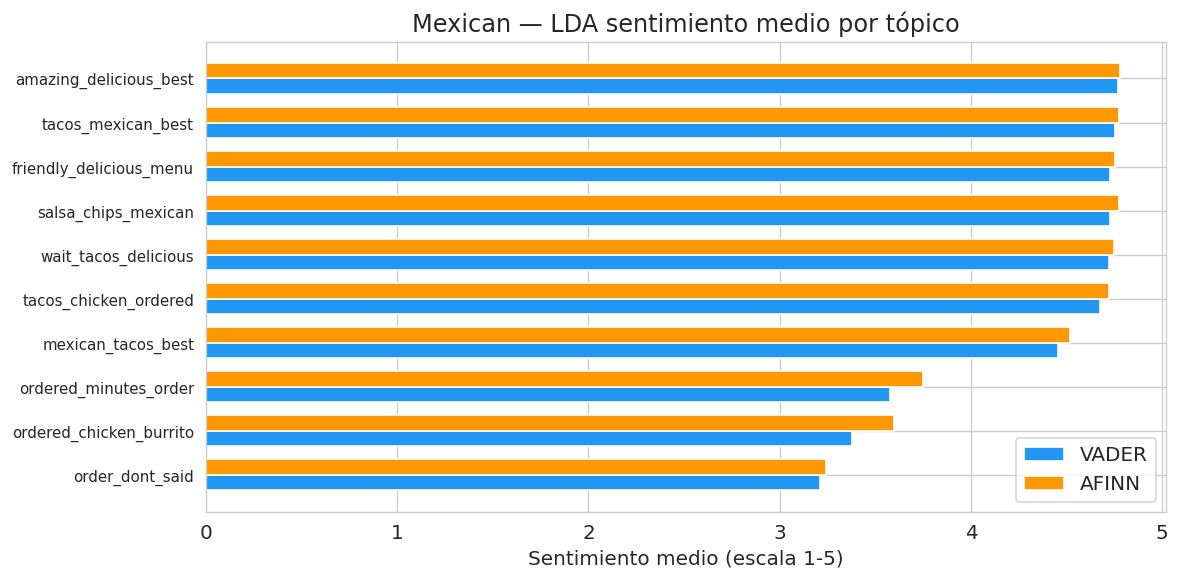


Análisis de polaridad: Mexican - LDA
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'order_dont_said' (VADER medio: 3.210 | Menciones: 48460)
'ordered_chicken_burrito' (VADER medio: 3.378 | Menciones: 43451)
'ordered_minutes_order' (VADER medio: 3.576 | Menciones: 29596)

Tópicos más positivos):
'amazing_delicious_best' (VADER medio: 4.766 | Menciones: 26214)
'tacos_mexican_best' (VADER medio: 4.753 | Menciones: 87562)
'friendly_delicious_menu' (VADER medio: 4.727 | Menciones: 30423)
---------------------------------------------------------------------------


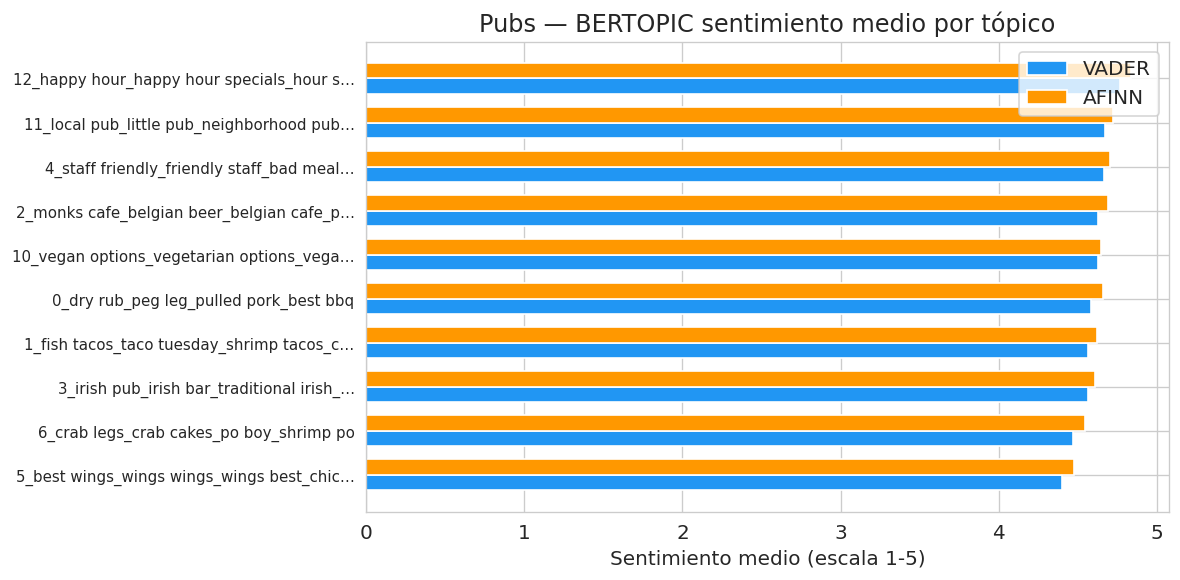


Análisis de polaridad: Pubs - BERTOPIC
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'5_best wings_wings wings_wings best_chic…' (VADER medio: 4.401 | Menciones: 1866)
'6_crab legs_crab cakes_po boy_shrimp po' (VADER medio: 4.471 | Menciones: 1878)
'3_irish pub_irish bar_traditional irish_…' (VADER medio: 4.566 | Menciones: 1881)

Tópicos más positivos):
'12_happy hour_happy hour specials_hour s…' (VADER medio: 4.768 | Menciones: 1352)
'11_local pub_little pub_neighborhood pub…' (VADER medio: 4.675 | Menciones: 1283)
'4_staff friendly_friendly staff_bad meal…' (VADER medio: 4.667 | Menciones: 1700)
---------------------------------------------------------------------------


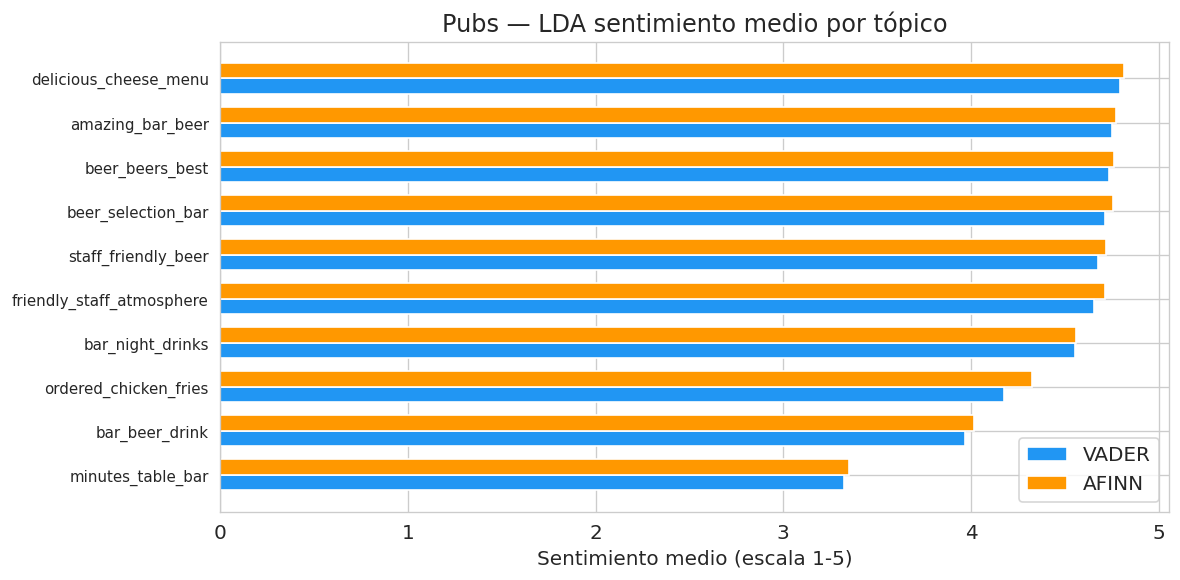


Análisis de polaridad: Pubs - LDA
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'minutes_table_bar' (VADER medio: 3.322 | Menciones: 27568)
'bar_beer_drink' (VADER medio: 3.971 | Menciones: 12224)
'ordered_chicken_fries' (VADER medio: 4.175 | Menciones: 27129)

Tópicos más positivos):
'delicious_cheese_menu' (VADER medio: 4.793 | Menciones: 38333)
'amazing_bar_beer' (VADER medio: 4.750 | Menciones: 11650)
'beer_beers_best' (VADER medio: 4.734 | Menciones: 16327)
---------------------------------------------------------------------------


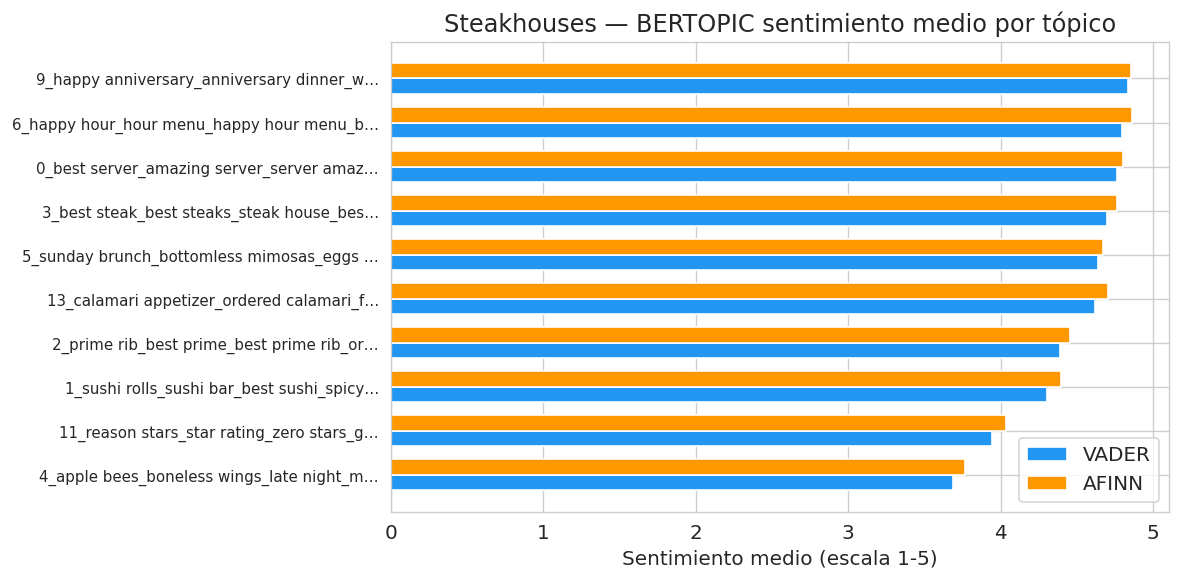


Análisis de polaridad: Steakhouses - BERTOPIC
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'4_apple bees_boneless wings_late night_m…' (VADER medio: 3.688 | Menciones: 2029)
'11_reason stars_star rating_zero stars_g…' (VADER medio: 3.939 | Menciones: 1271)
'1_sushi rolls_sushi bar_best sushi_spicy…' (VADER medio: 4.300 | Menciones: 2706)

Tópicos más positivos):
'9_happy anniversary_anniversary dinner_w…' (VADER medio: 4.836 | Menciones: 1307)
'6_happy hour_hour menu_happy hour menu_b…' (VADER medio: 4.791 | Menciones: 1589)
'0_best server_amazing server_server amaz…' (VADER medio: 4.764 | Menciones: 3144)
---------------------------------------------------------------------------


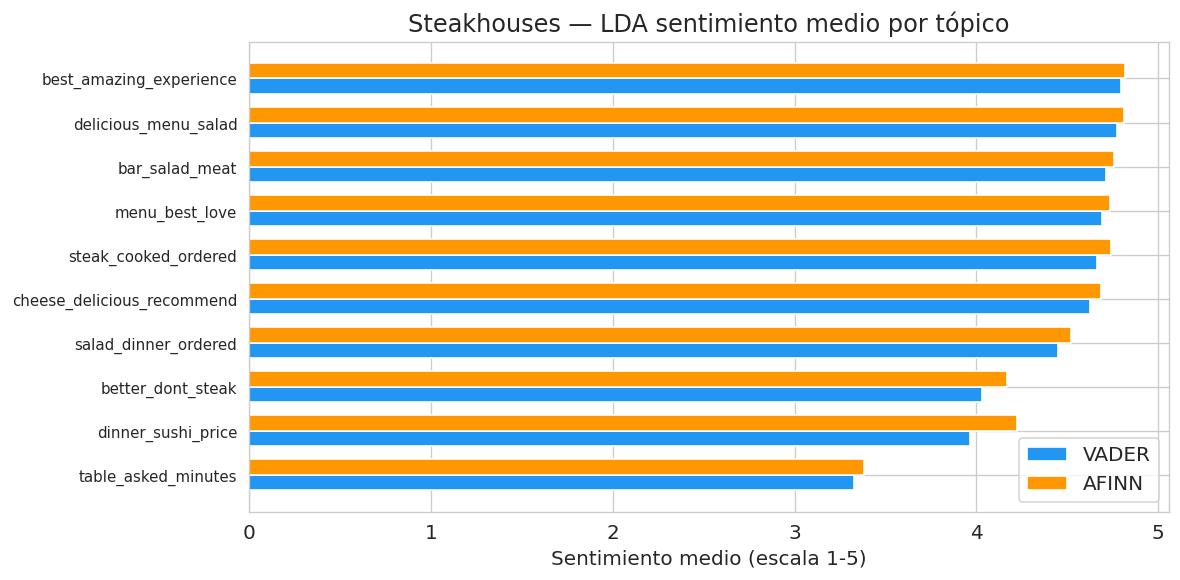


Análisis de polaridad: Steakhouses - LDA
Basado en los 10 tópicos con más volumen de reseñas (ranking según VADER):

Tópicos más negativos:
'table_asked_minutes' (VADER medio: 3.328 | Menciones: 44797)
'dinner_sushi_price' (VADER medio: 3.964 | Menciones: 10609)
'better_dont_steak' (VADER medio: 4.029 | Menciones: 23169)

Tópicos más positivos):
'best_amazing_experience' (VADER medio: 4.793 | Menciones: 46093)
'delicious_menu_salad' (VADER medio: 4.771 | Menciones: 26199)
'bar_salad_meat' (VADER medio: 4.710 | Menciones: 10778)
---------------------------------------------------------------------------


In [9]:
def plot_mean_sentiment_by_topic(category_dfs, categories, topic_models, top_n=10):
    """
    Para cada categoría y modelo de tópicos, genera un gráfico de barras horizontal
    con la media de VADER y AFINN por tópico. Además, imprime por consola los 
    tópicos más positivos y negativos para facilitar el análisis.

    Args:
        category_dfs (dict): Diccionario donde las claves son las categorías y los valores son DataFrames de Polars con los datos.
        categories (list<str>): Lista con los nombres de las categorías a analizar.
        topic_models (dict): Diccionario que relaciona el nombre del modelo con su columna correspondiente.
        top_n (int): Número máximo de tópicos principales a mostrar (basado en el volumen de reseñas). Por defecto es 10.
    """
    for cat in categories:
        df = category_dfs[cat]
        for model_name, topic_col in topic_models.items():
            # Filtrar tópico -1 para BERTopic (el tópico -1 es la categoría de ruido)
            work_df = df
            if model_name == 'bertopic':
                work_df = df.filter(~pl.col(topic_col).str.starts_with('-1'))

            agg = (
                work_df
                .group_by(topic_col)
                .agg([
                    pl.col('vader_score').mean().alias('vader_mean'),
                    pl.col('afinn_score').mean().alias('afinn_mean'),
                    pl.col('review_id').count().alias('count'),
                ])
                .sort('count', descending=True)
                .head(top_n)
                .sort('vader_mean', descending=False) 
            ).to_pandas()

            agg['label'] = agg[topic_col].apply(lambda x: x[:40] + '…' if len(str(x)) > 40 else str(x))

            fig, ax = plt.subplots(figsize=(10, max(4, len(agg) * 0.5)))
            y = np.arange(len(agg))
            h = 0.35
            ax.barh(y - h/2, agg['vader_mean'], h, label='VADER', color='#2196F3')
            ax.barh(y + h/2, agg['afinn_mean'], h, label='AFINN', color='#FF9800')
            ax.set_yticks(y)
            ax.set_yticklabels(agg['label'], fontsize=9)
            ax.set_xlabel('Sentimiento medio (escala 1-5)')
            ax.set_title(f'{cat.replace("_", " ").title()} — {model_name.upper()} sentimiento medio por tópico')
            ax.legend()
            plt.tight_layout()
            plt.show()

            num_to_show = min(3, len(agg))
            
            print(f"\nAnálisis de polaridad: {cat.replace('_', ' ').title()} - {model_name.upper()}")
            print(f"Basado en los {top_n} tópicos con más volumen de reseñas (ranking según VADER):")
            
            negativos = agg.head(num_to_show)
            print("\nTópicos más negativos:")
            for _, row in negativos.iterrows():
                print(f"'{row['label']}' (VADER medio: {row['vader_mean']:.3f} | Menciones: {row['count']})")
                
            positivos = agg.tail(num_to_show).iloc[::-1]
            print("\nTópicos más positivos):")
            for _, row in positivos.iterrows():
                print(f"'{row['label']}' (VADER medio: {row['vader_mean']:.3f} | Menciones: {row['count']})")

plot_mean_sentiment_by_topic(category_dfs, categories, topic_models, top_n)

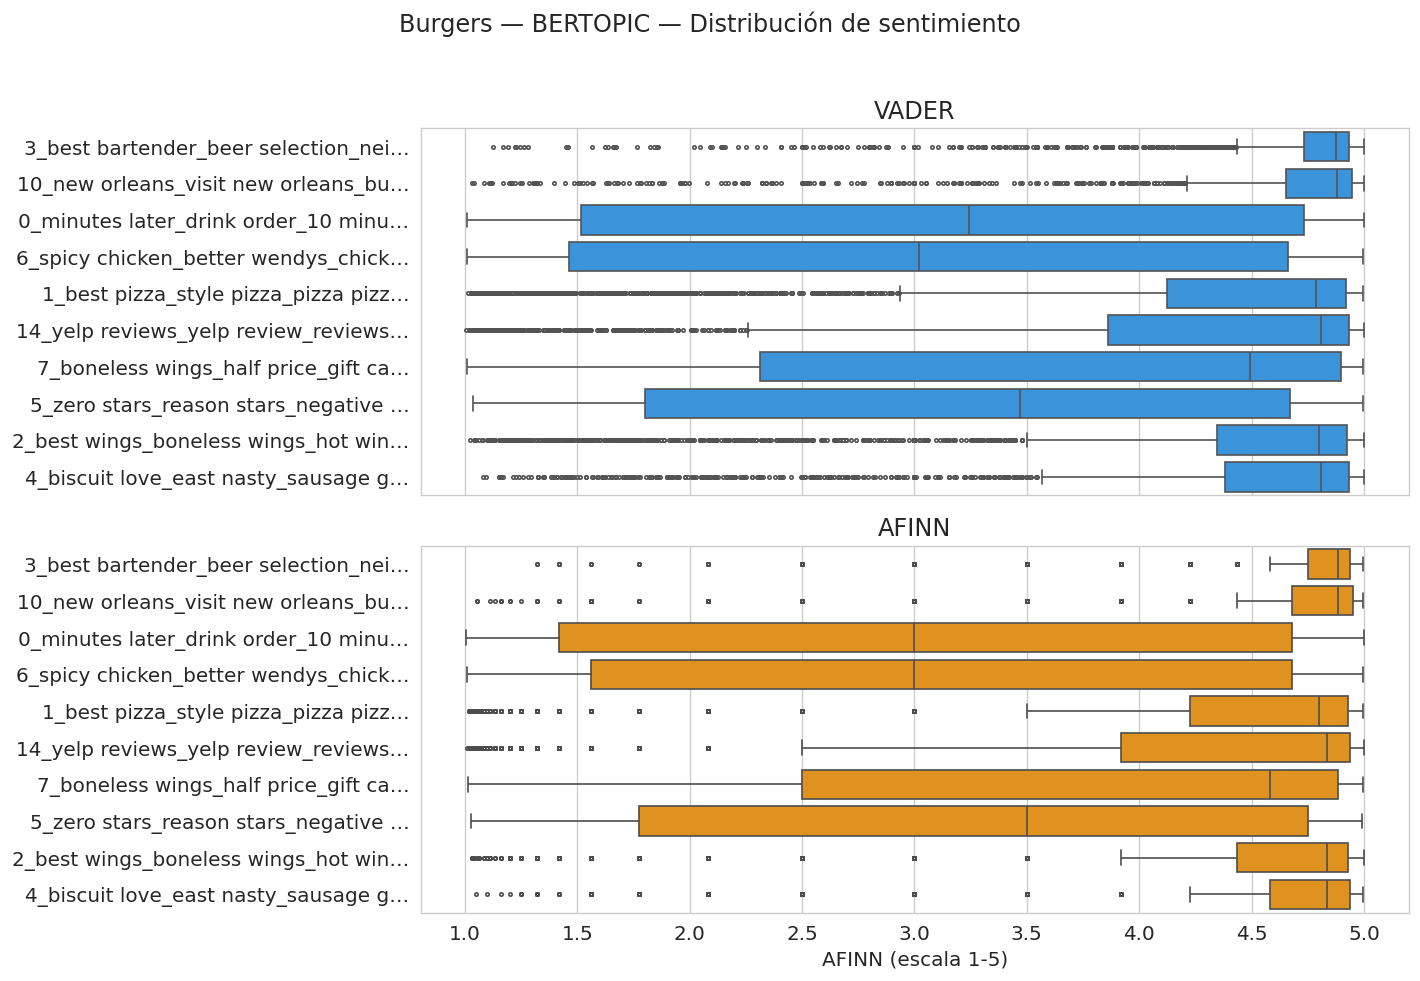

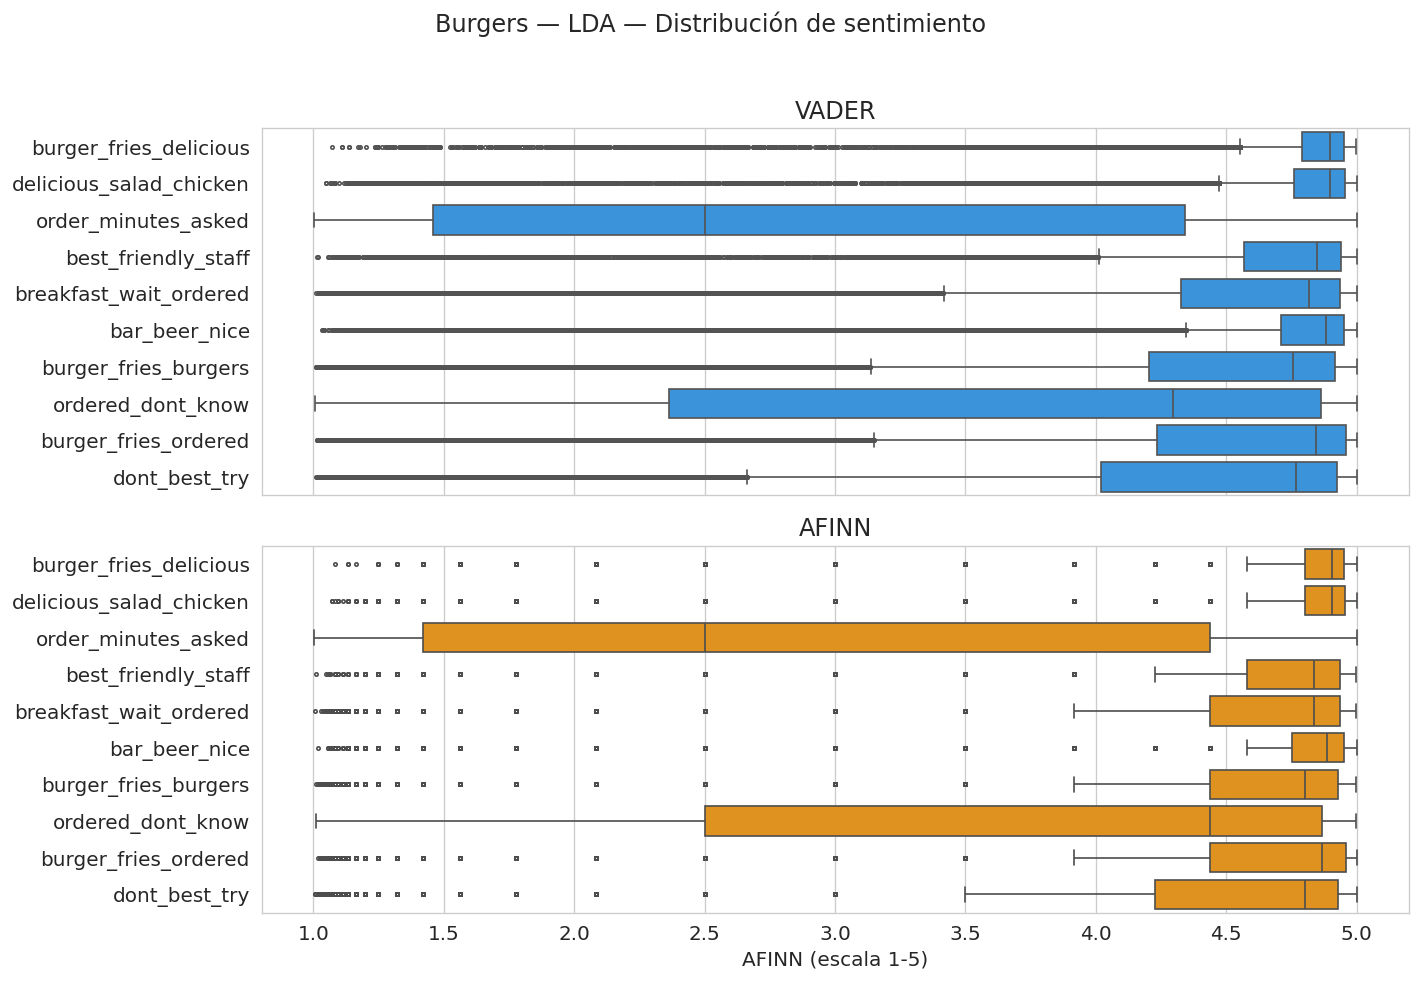

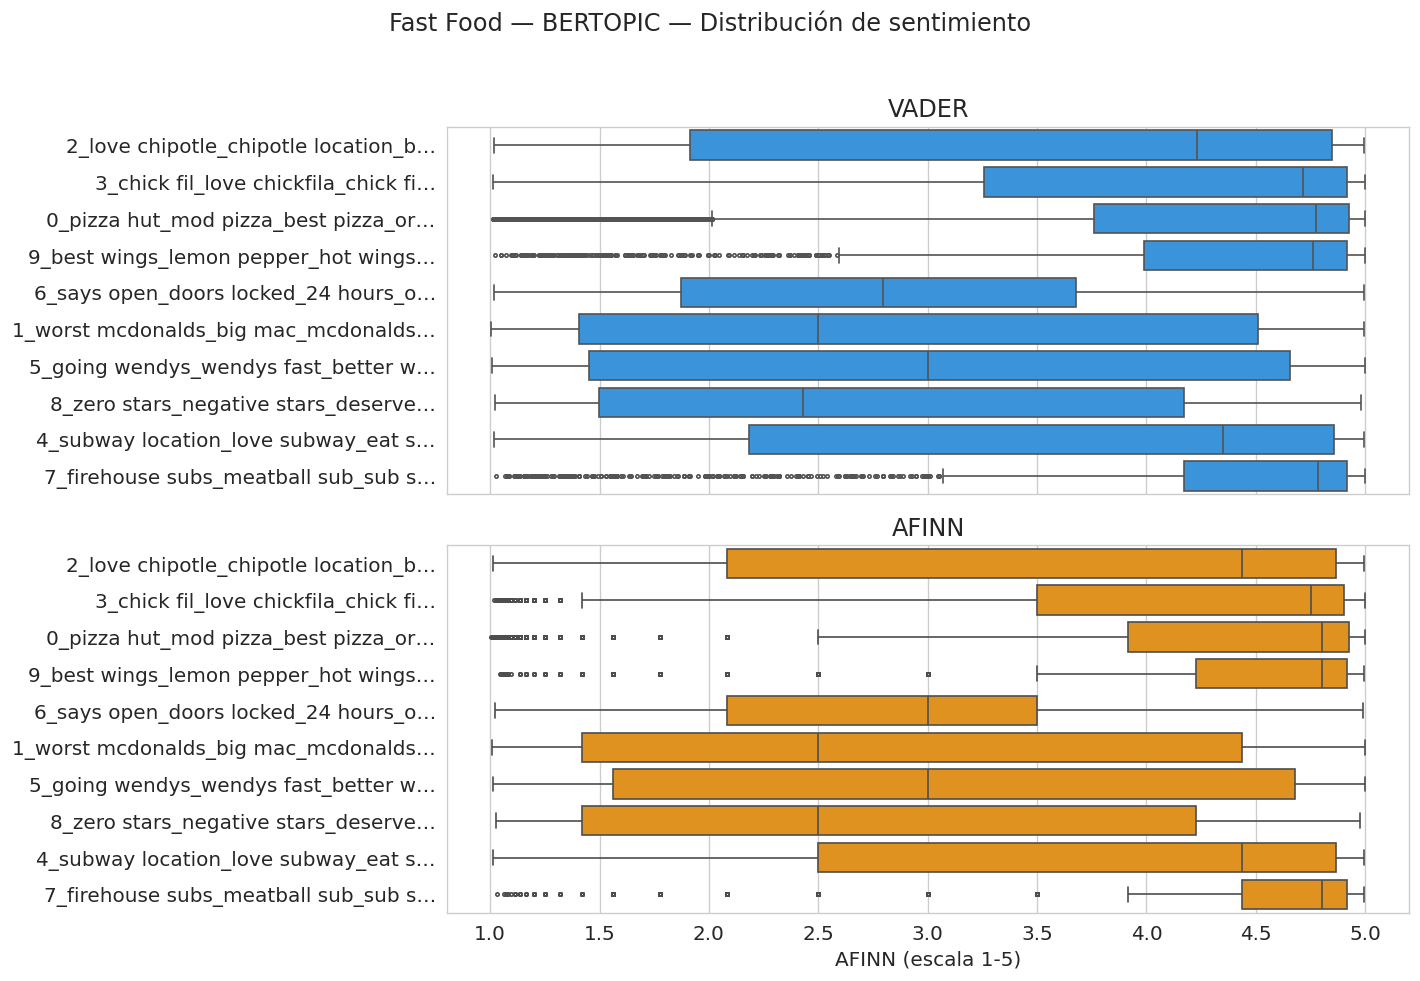

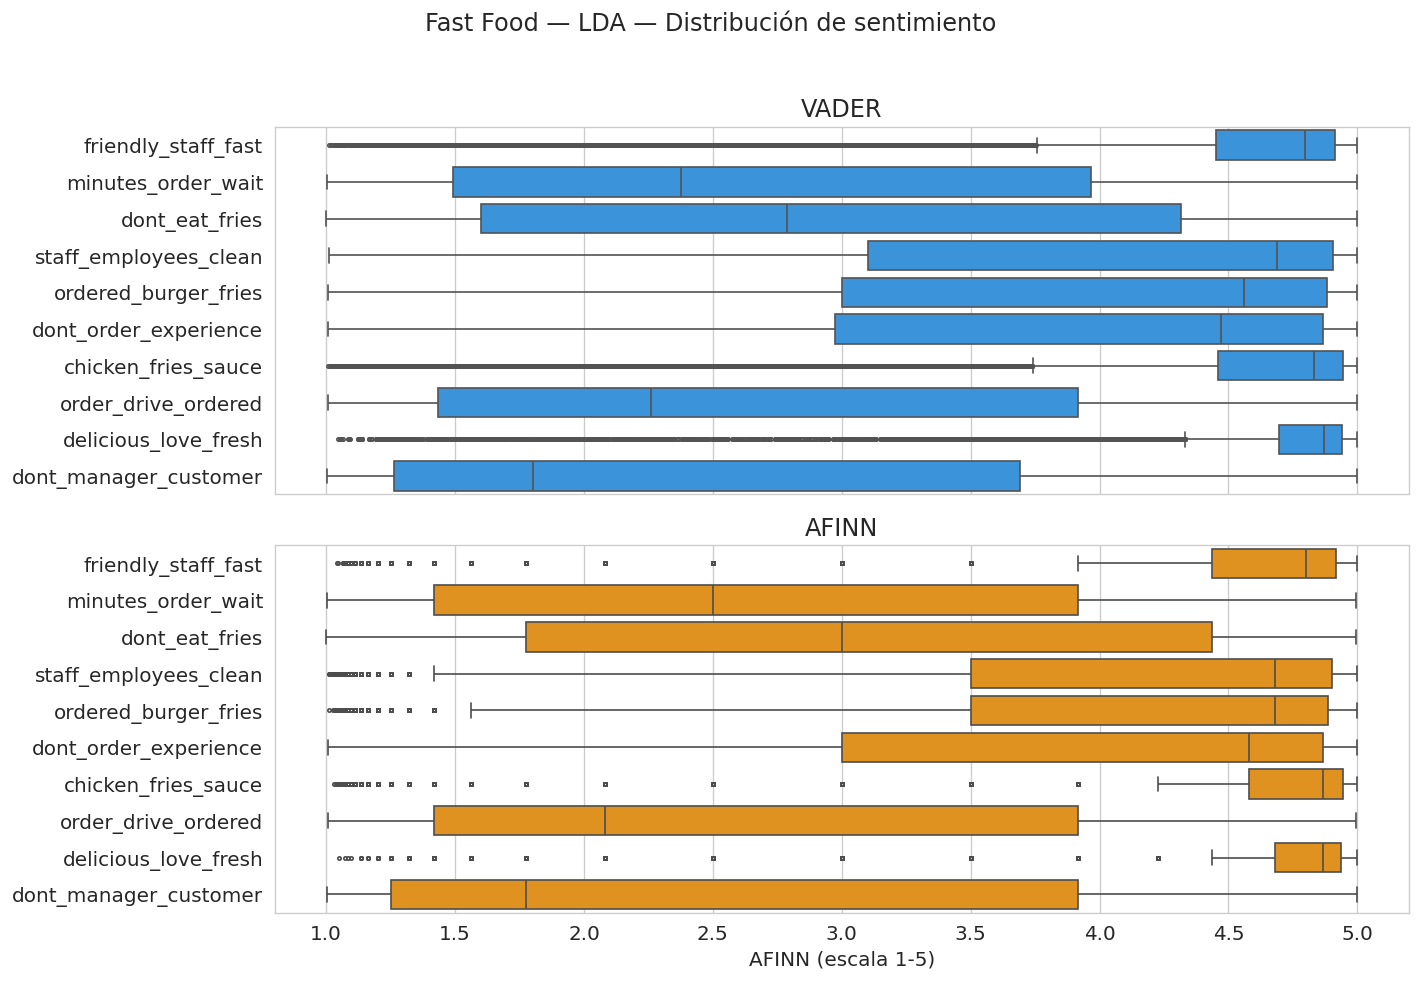

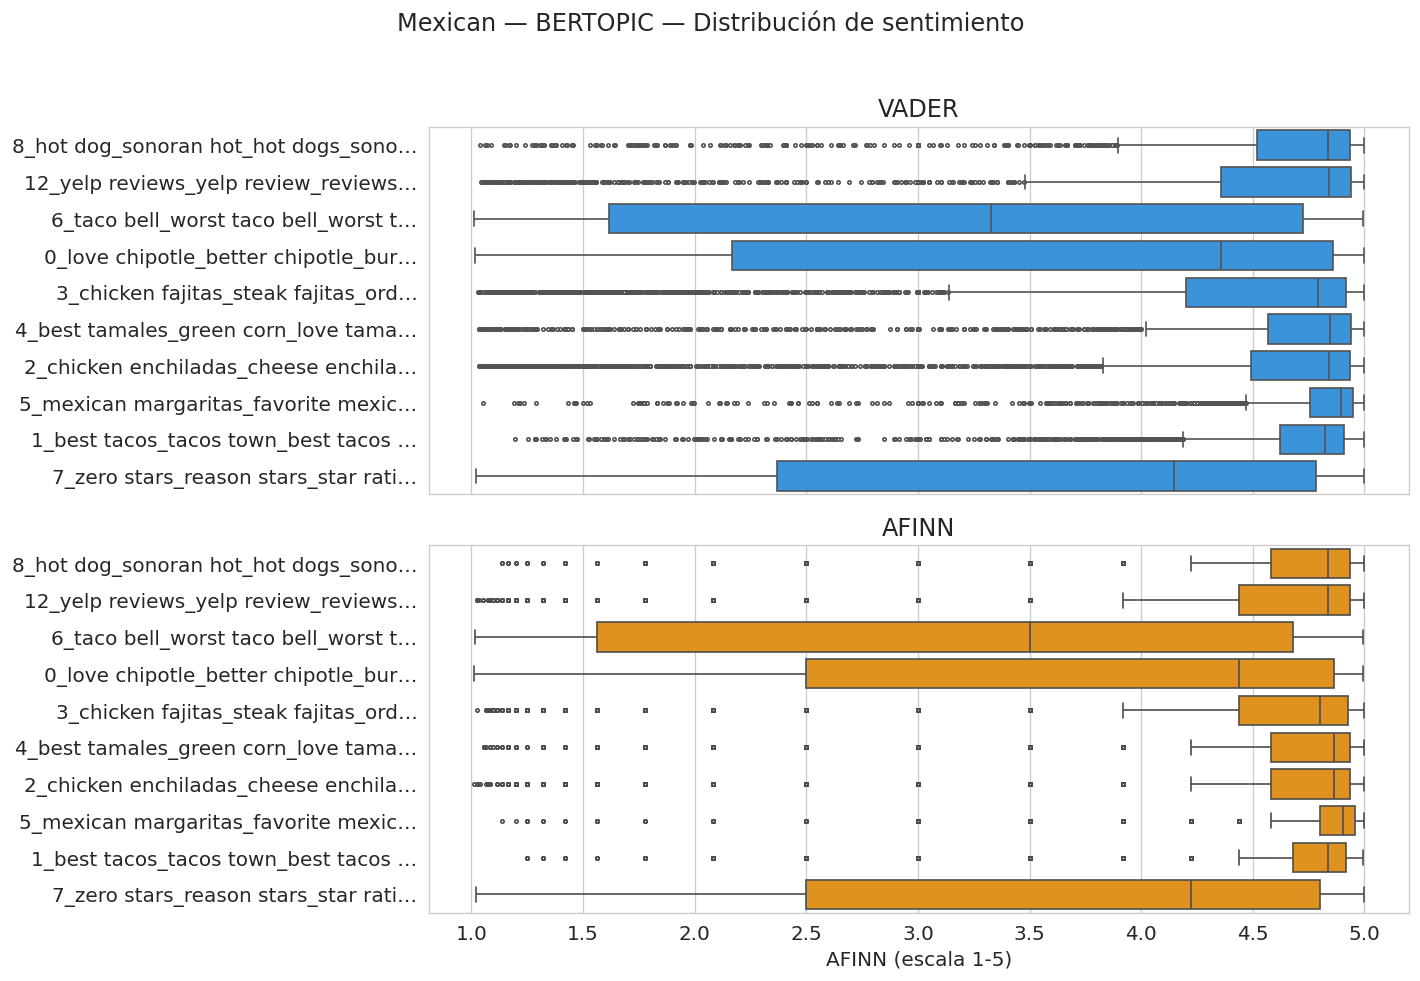

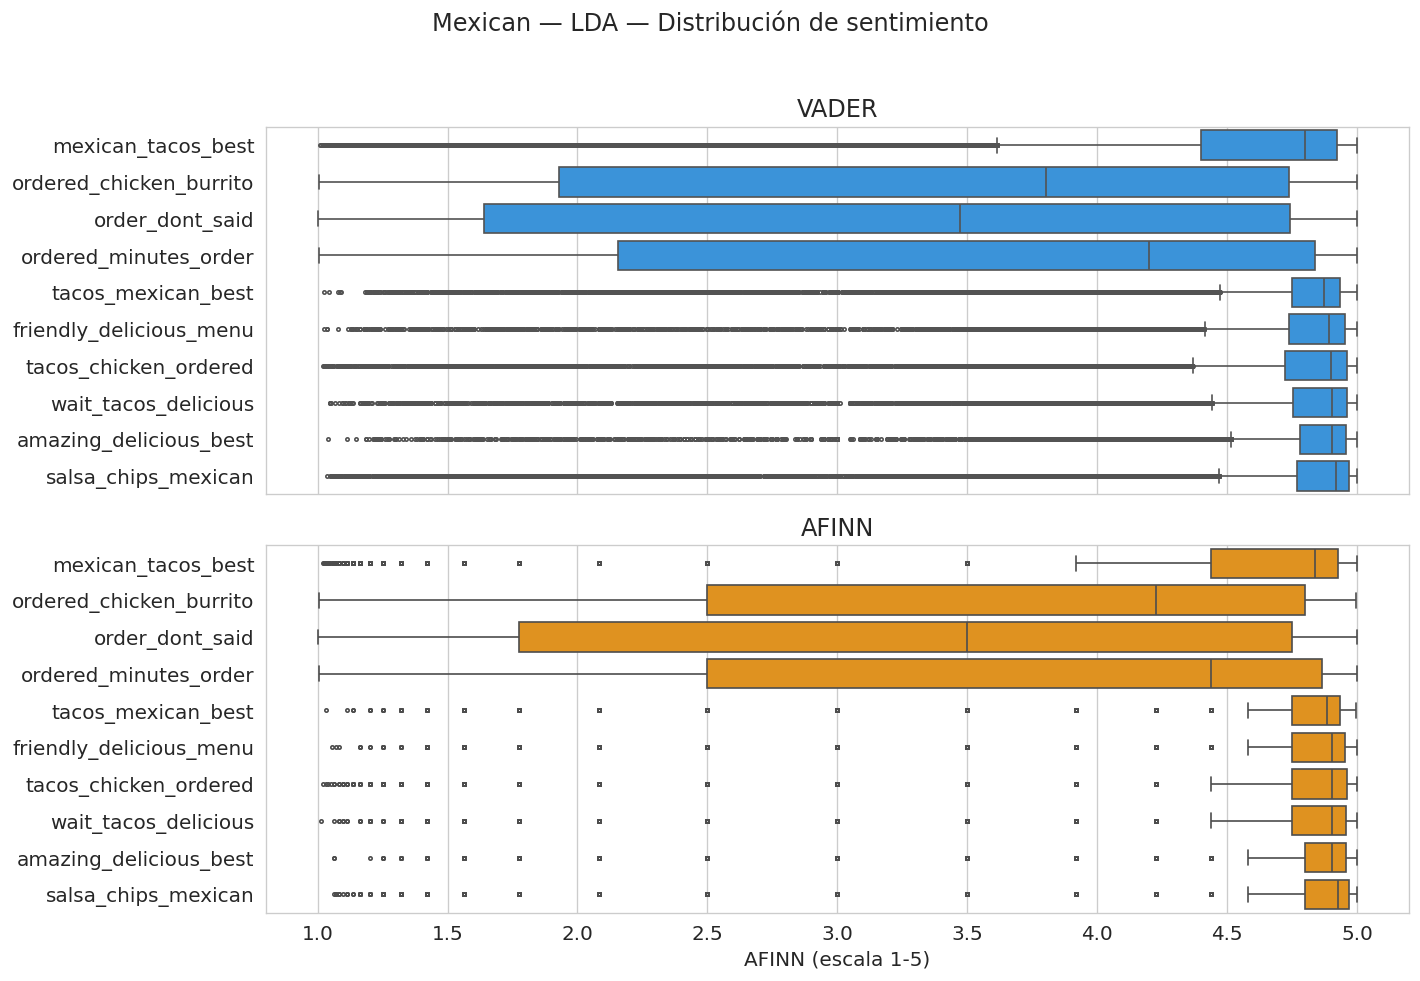

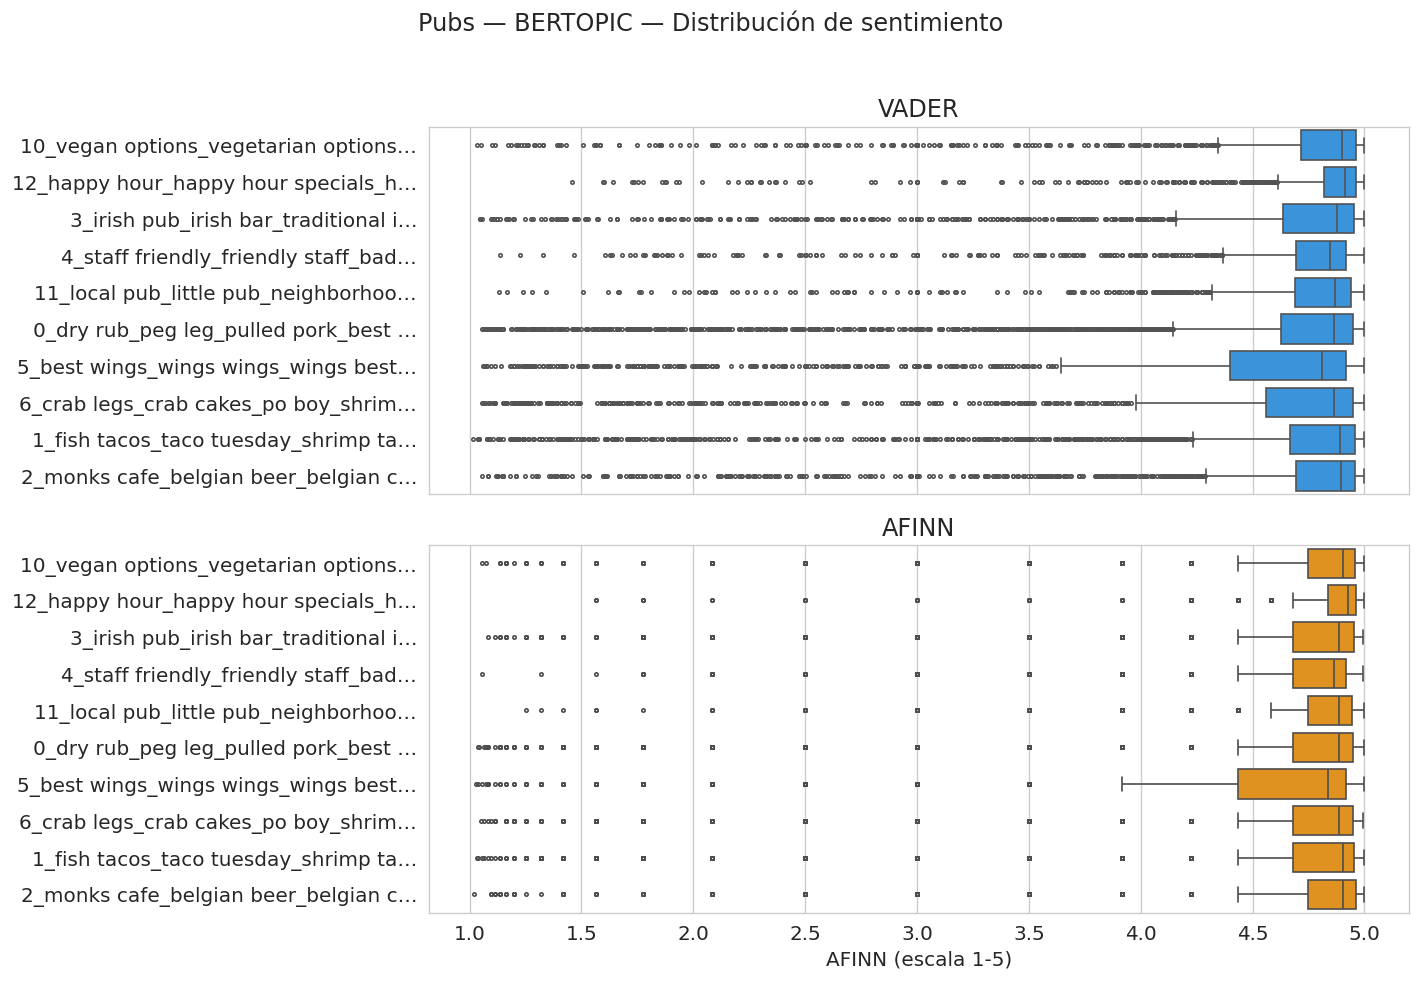

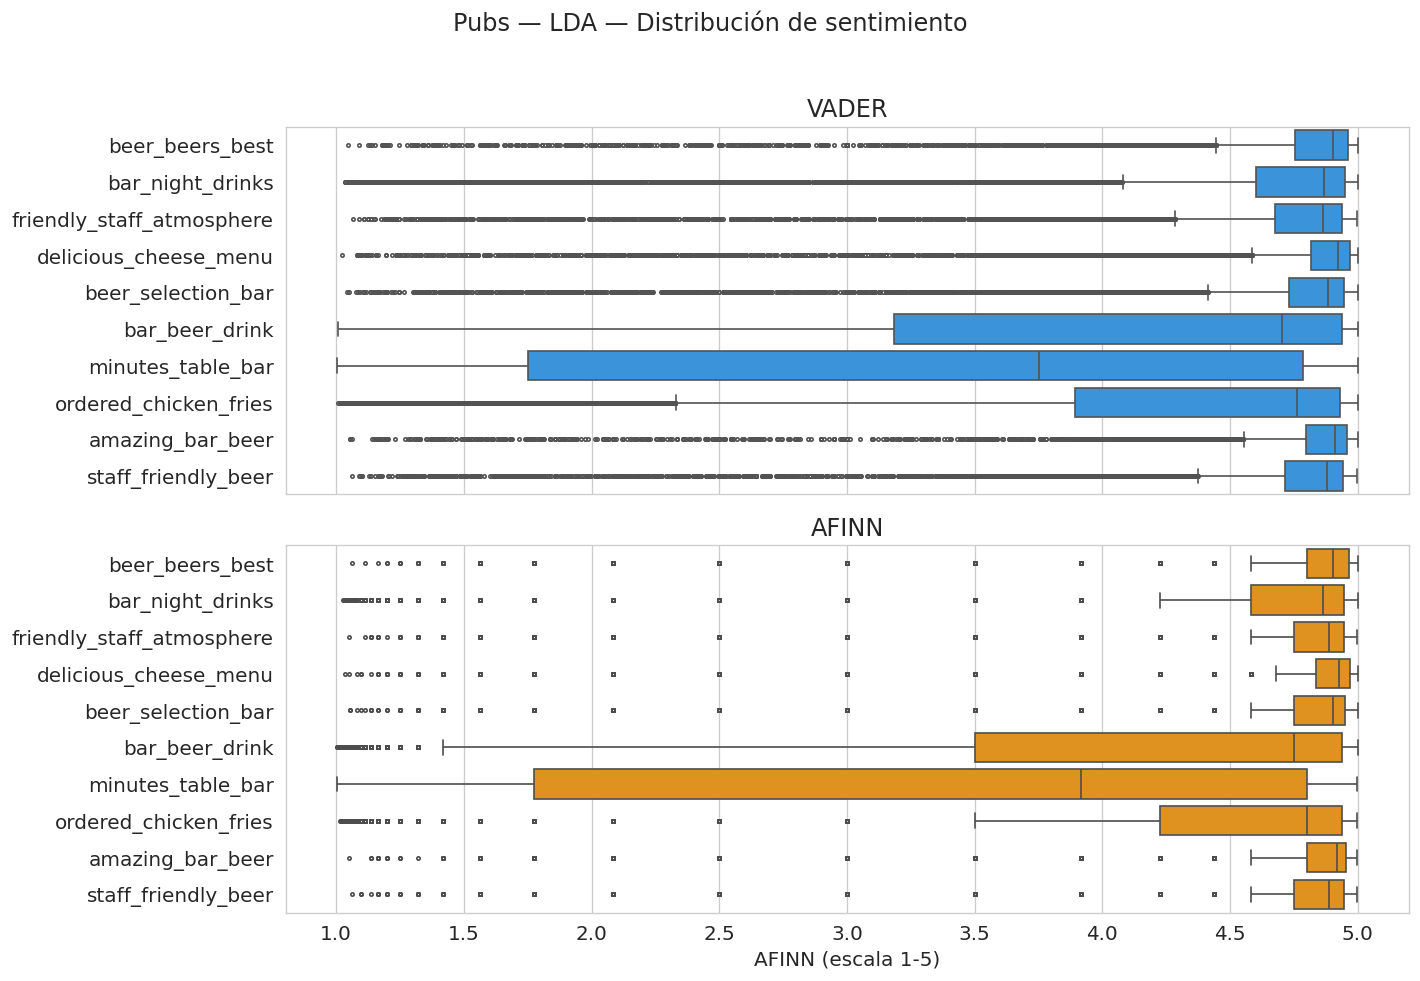

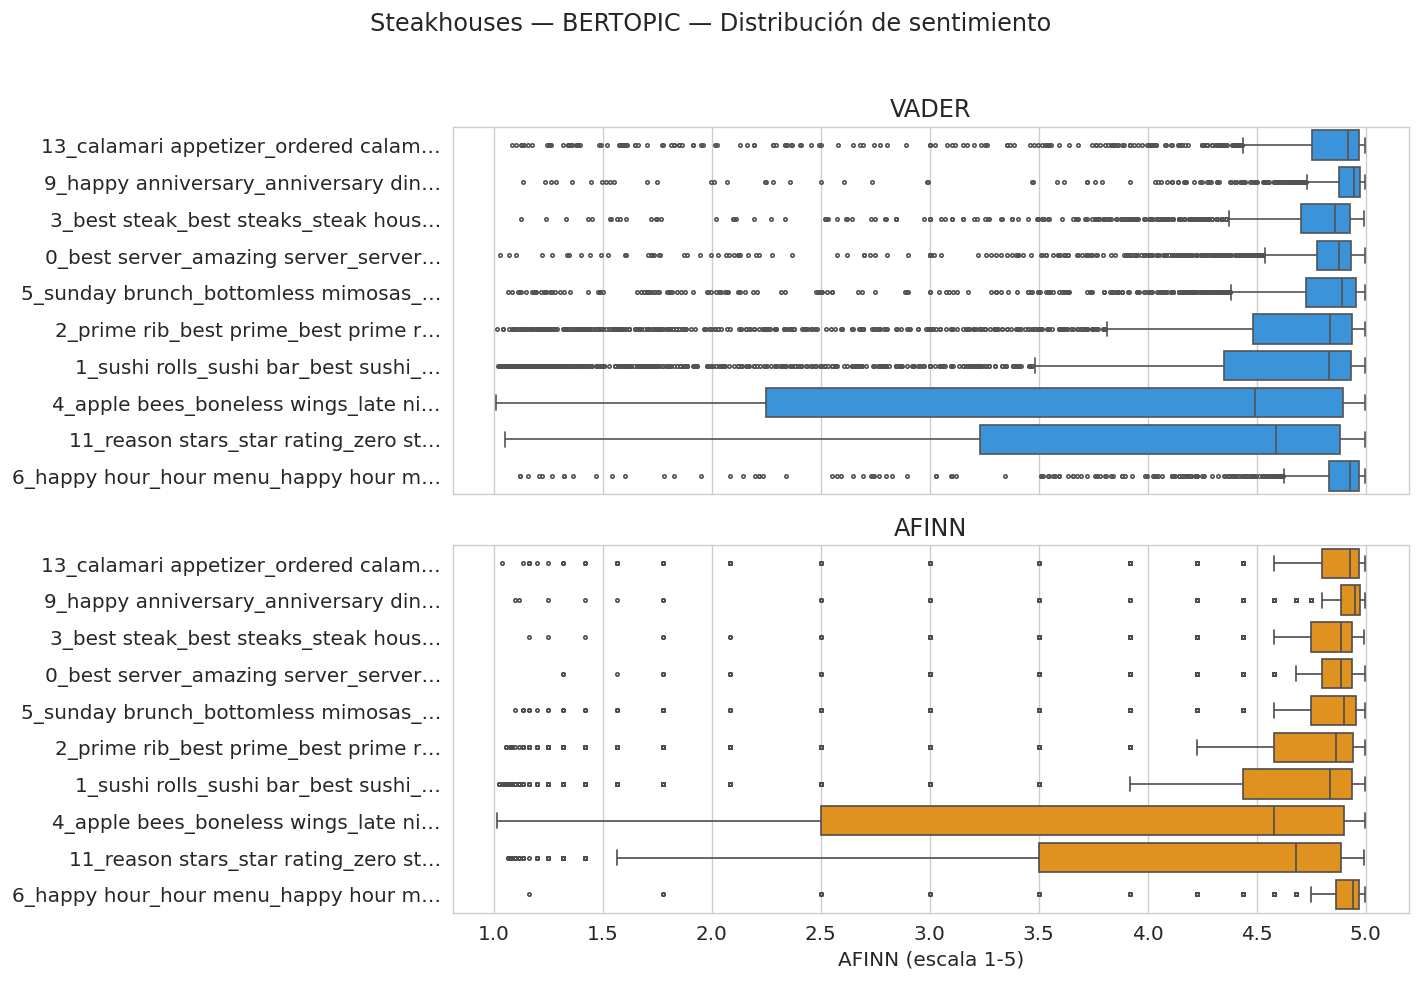

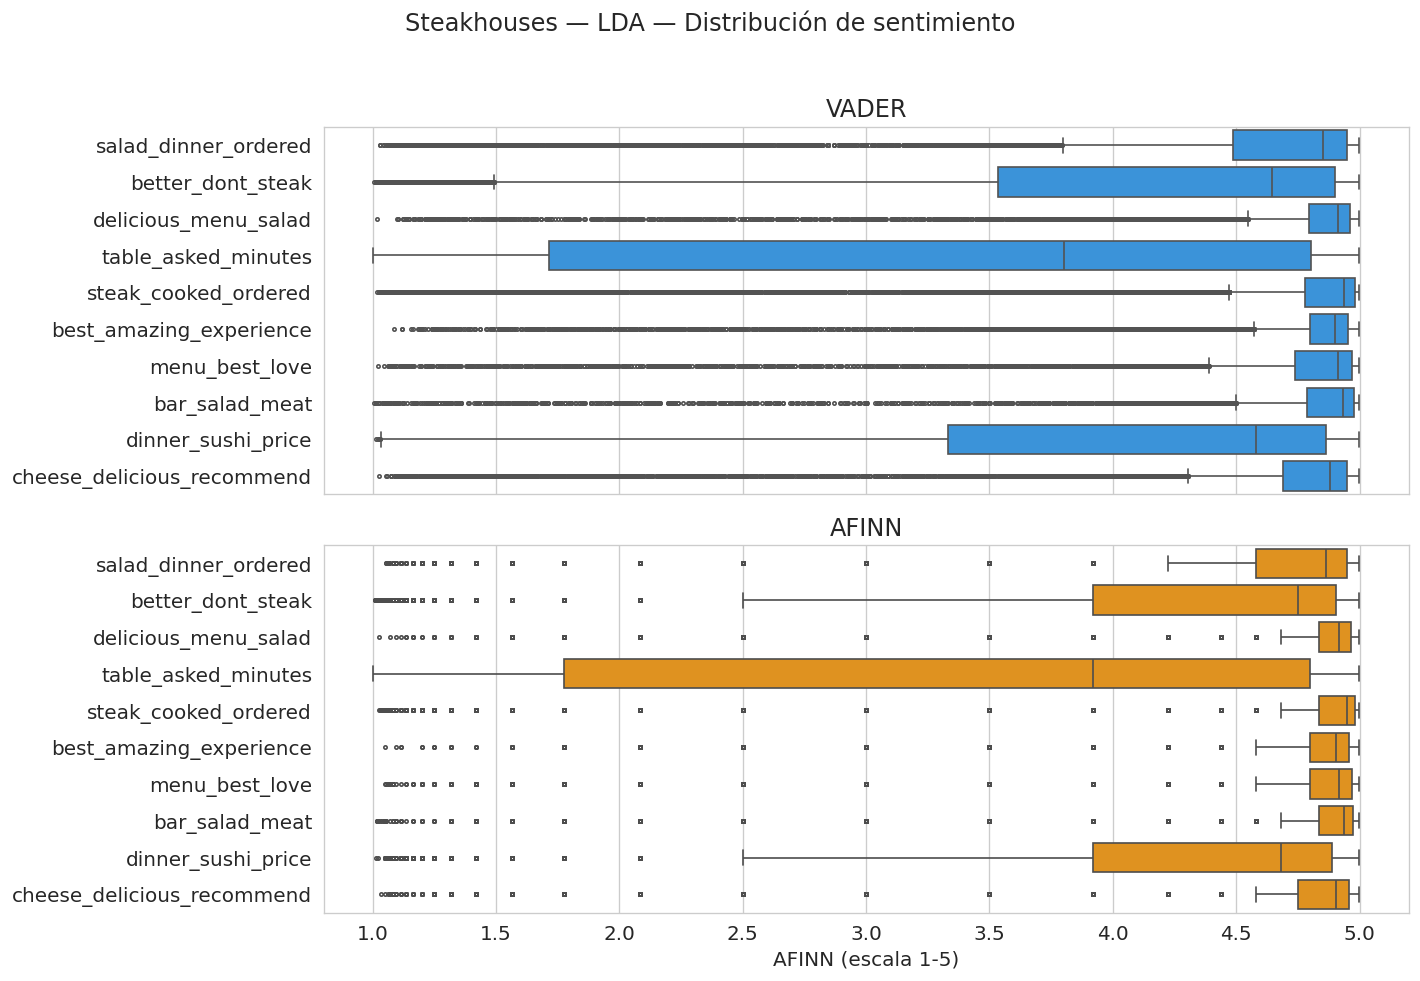

In [4]:
def plot_sentiment_distribution(category_dfs, categories, topic_models, top_n=10):
    """
    Box plots de VADER y AFINN por tópico (top-N por nº de reviews).
    """
    for cat in categories:
        df = category_dfs[cat]
        for model_name, topic_col in topic_models.items():
            work_df = df
            if model_name == 'bertopic':
                work_df = df.filter(~pl.col(topic_col).str.starts_with('-1'))

            top_topics = (
                work_df.group_by(topic_col)
                .agg(pl.col('review_id').count().alias('count'))
                .sort('count', descending=True)
                .head(top_n)
                .get_column(topic_col)
                .to_list()
            )
            filtered = work_df.filter(pl.col(topic_col).is_in(top_topics)).to_pandas()
            filtered['label'] = filtered[topic_col].apply(lambda x: x[:35] + '…' if len(str(x)) > 35 else str(x))

            fig, axes = plt.subplots(2, 1, figsize=(12, max(6, len(top_topics) * 0.8)), sharex=True)

            for i, (score_col, color, name) in enumerate([
                ('vader_score', '#2196F3', 'VADER'),
                ('afinn_score', '#FF9800', 'AFINN'),
            ]):
                sns.boxplot(
                    data=filtered, y='label', x=score_col,
                    orient='h', ax=axes[i], color=color,
                    fliersize=2,
                )
                axes[i].set_ylabel('')
                axes[i].set_xlabel(f'{name} (escala 1-5)')
                axes[i].set_title(f'{name}')

            fig.suptitle(f'{cat.replace("_", " ").title()} — {model_name.upper()} — Distribución de sentimiento', y=1.02)
            plt.tight_layout()
            plt.show()


plot_sentiment_distribution(category_dfs, categories, topic_models, top_n)

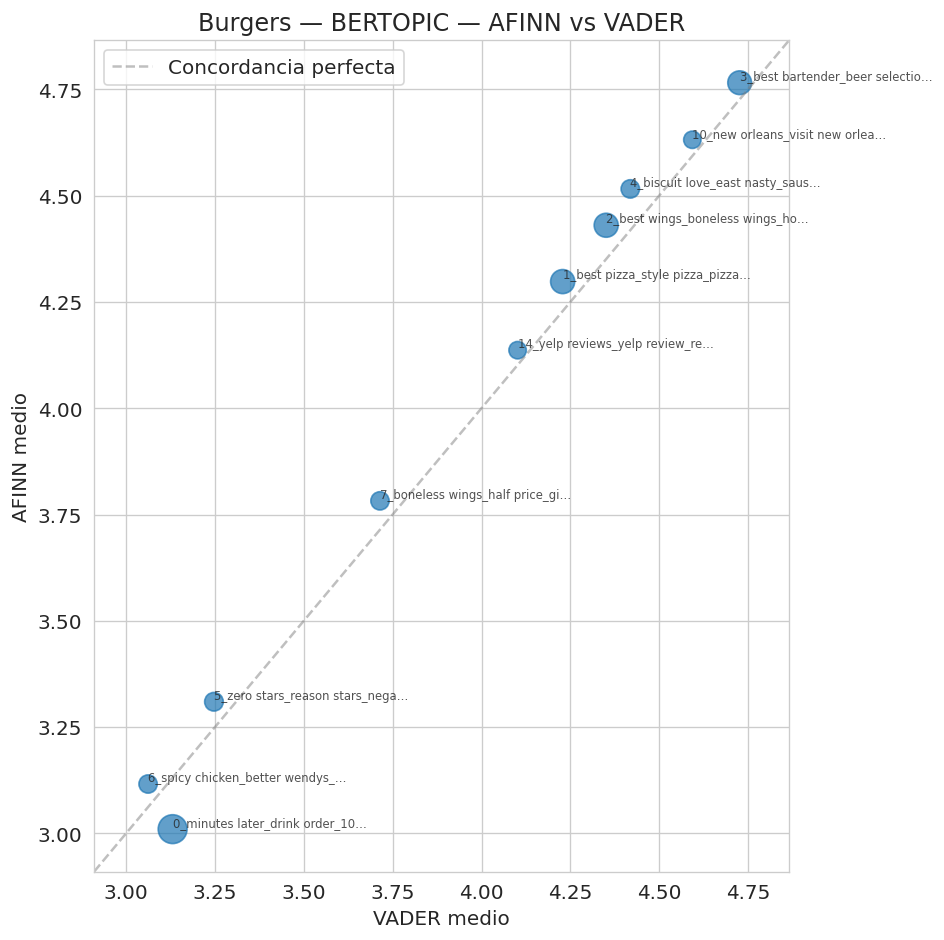

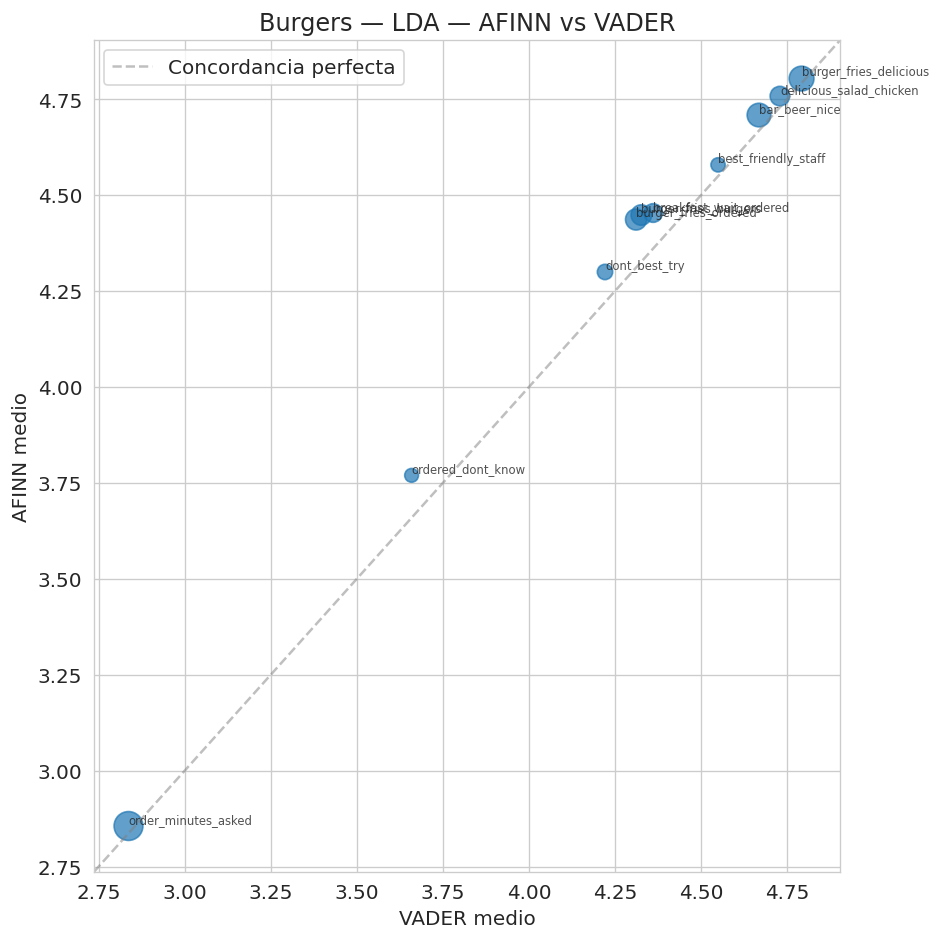

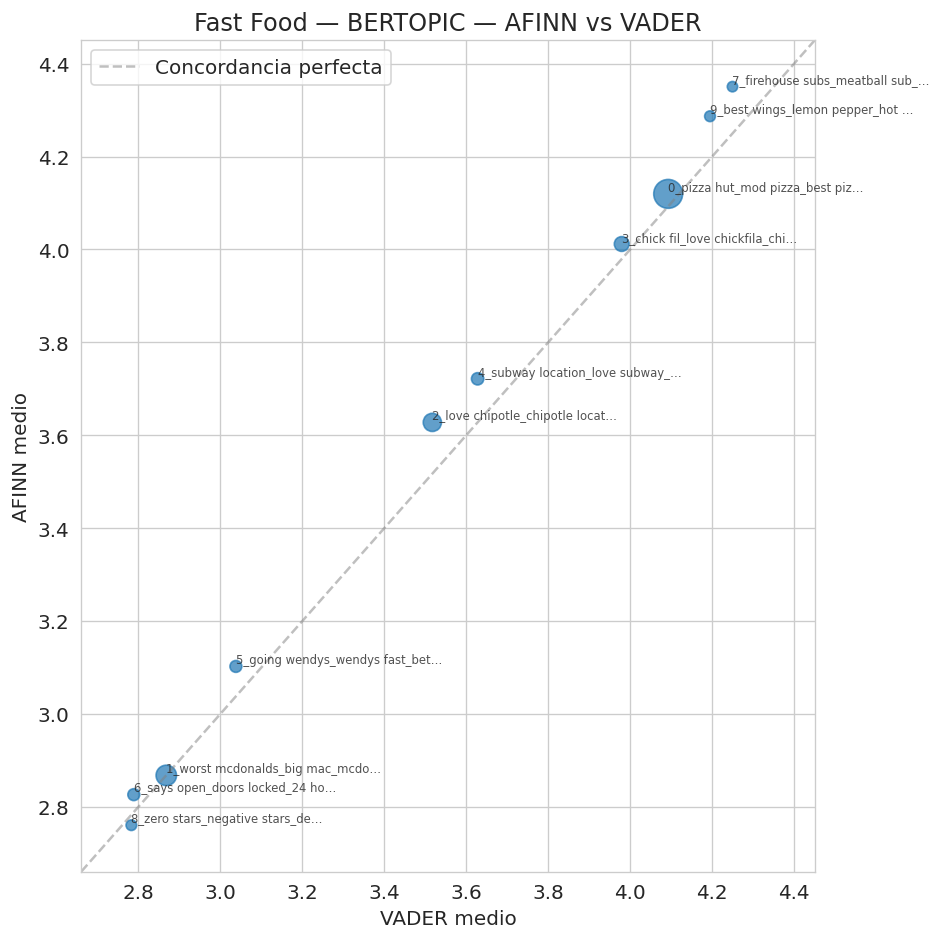

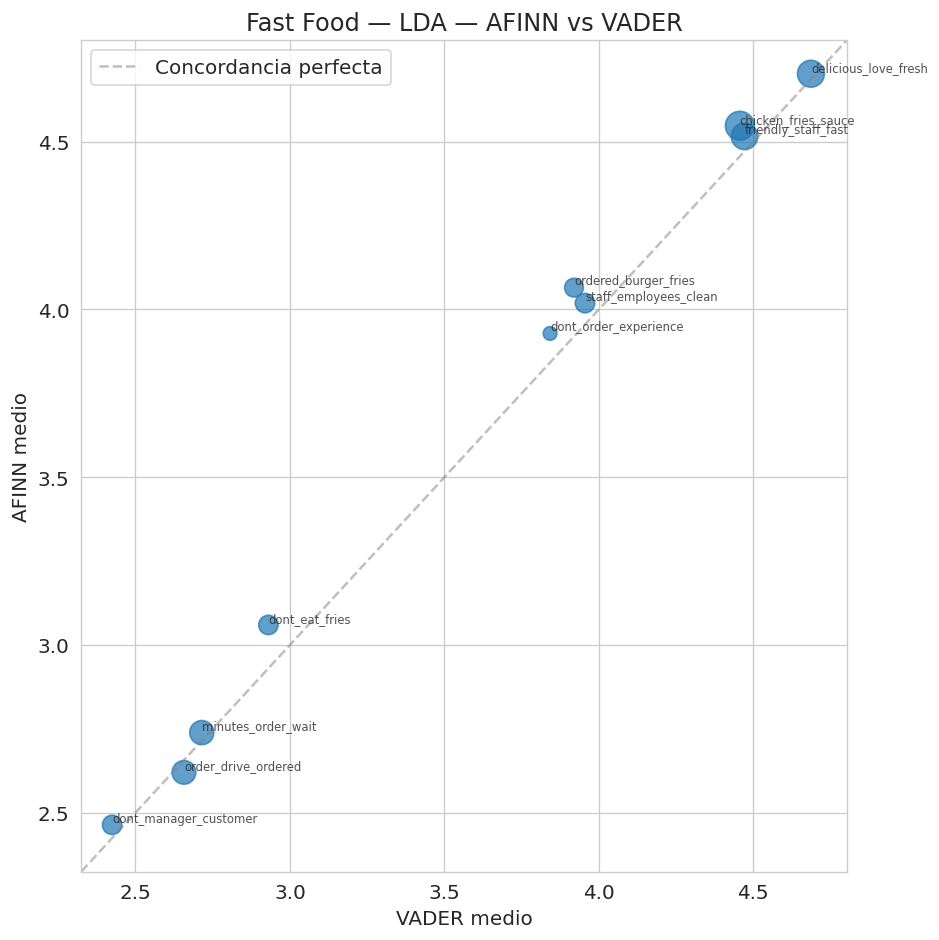

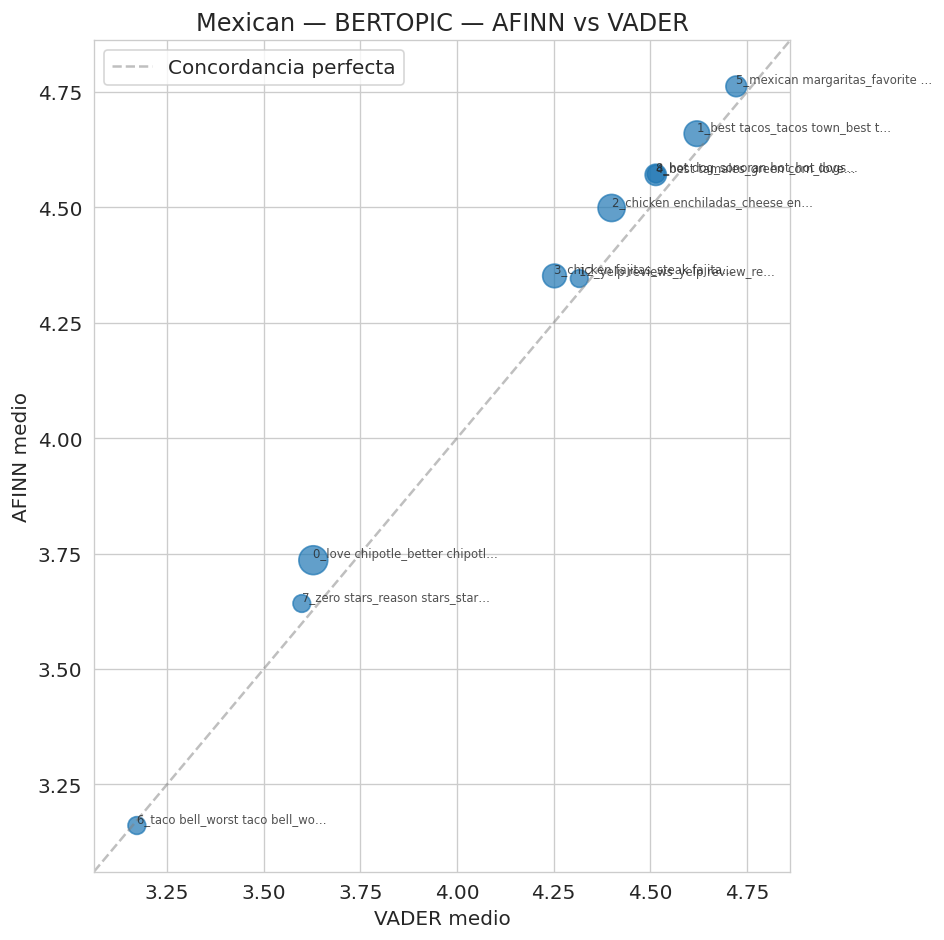

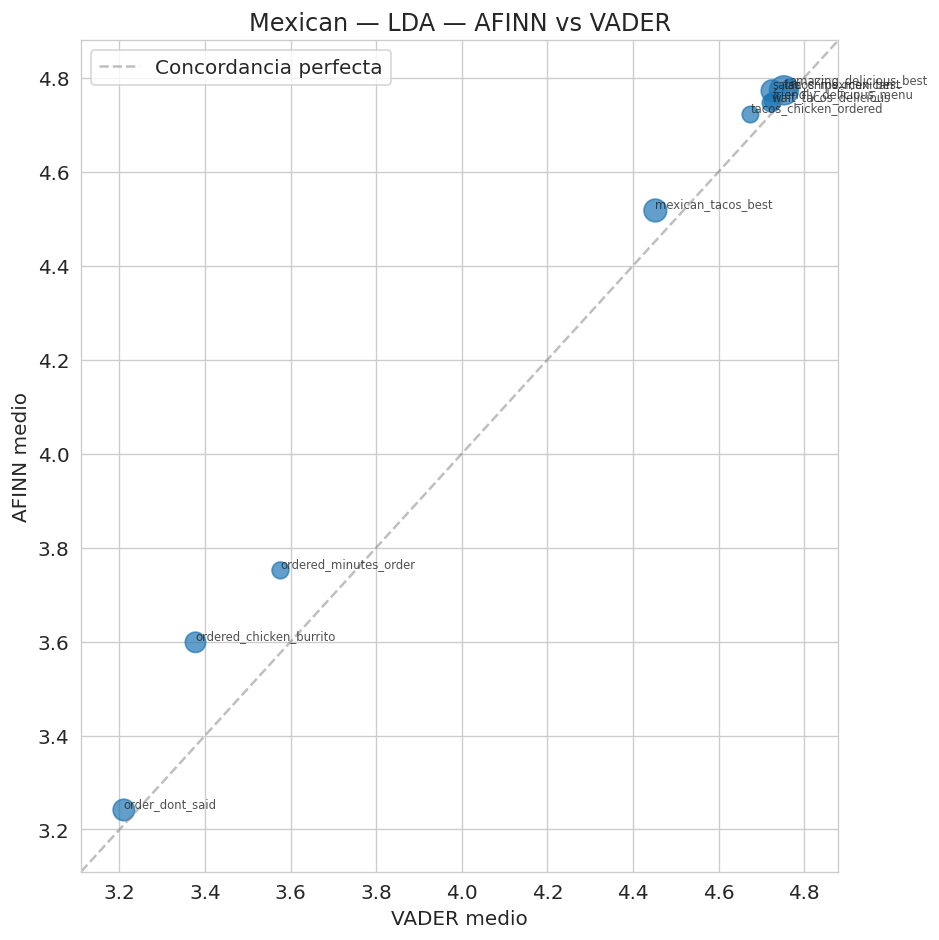

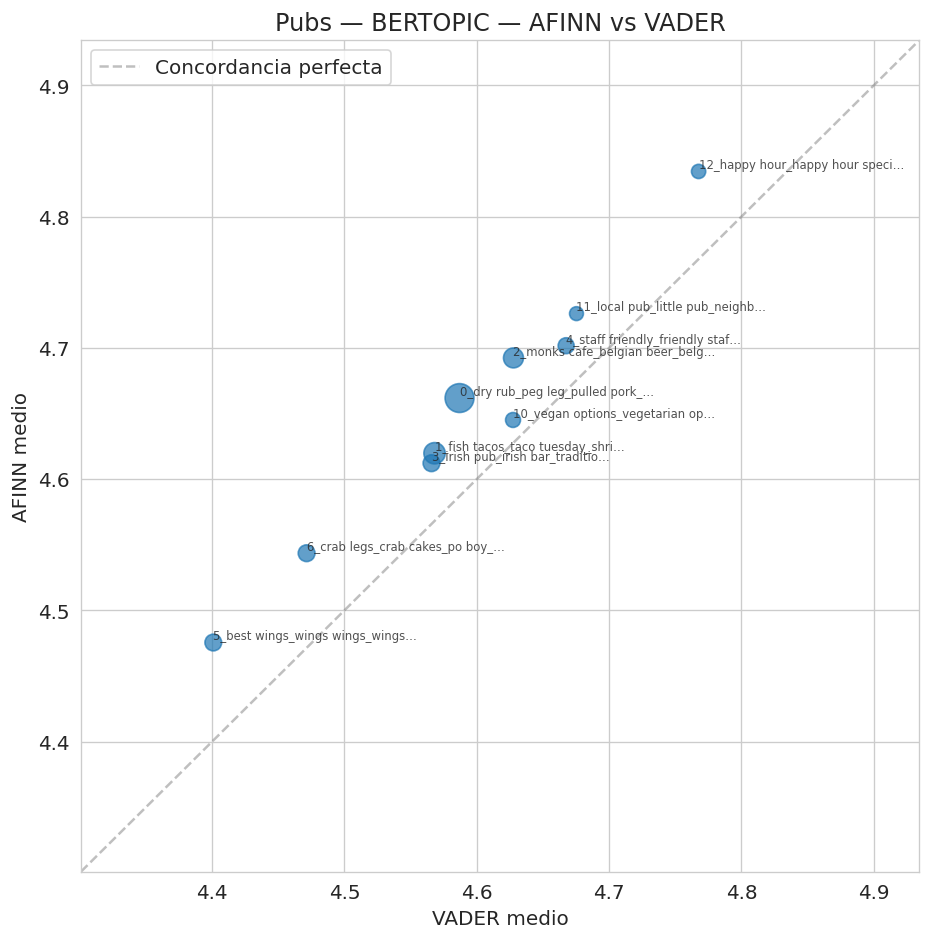

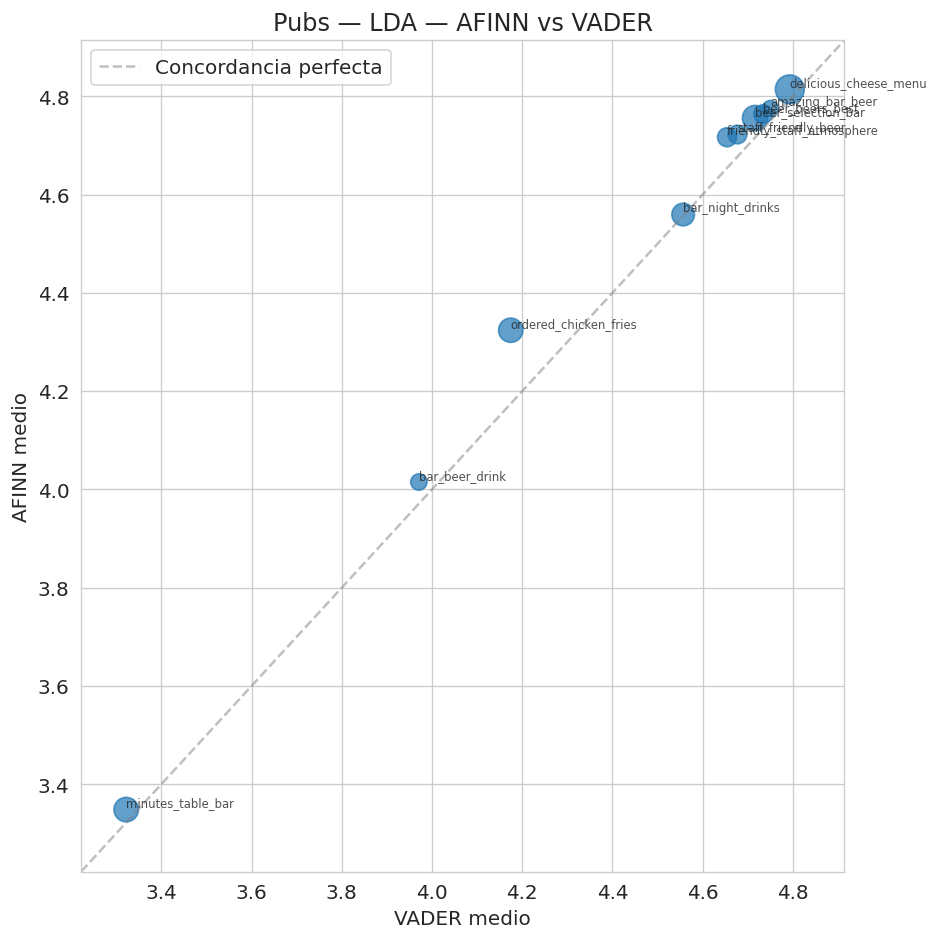

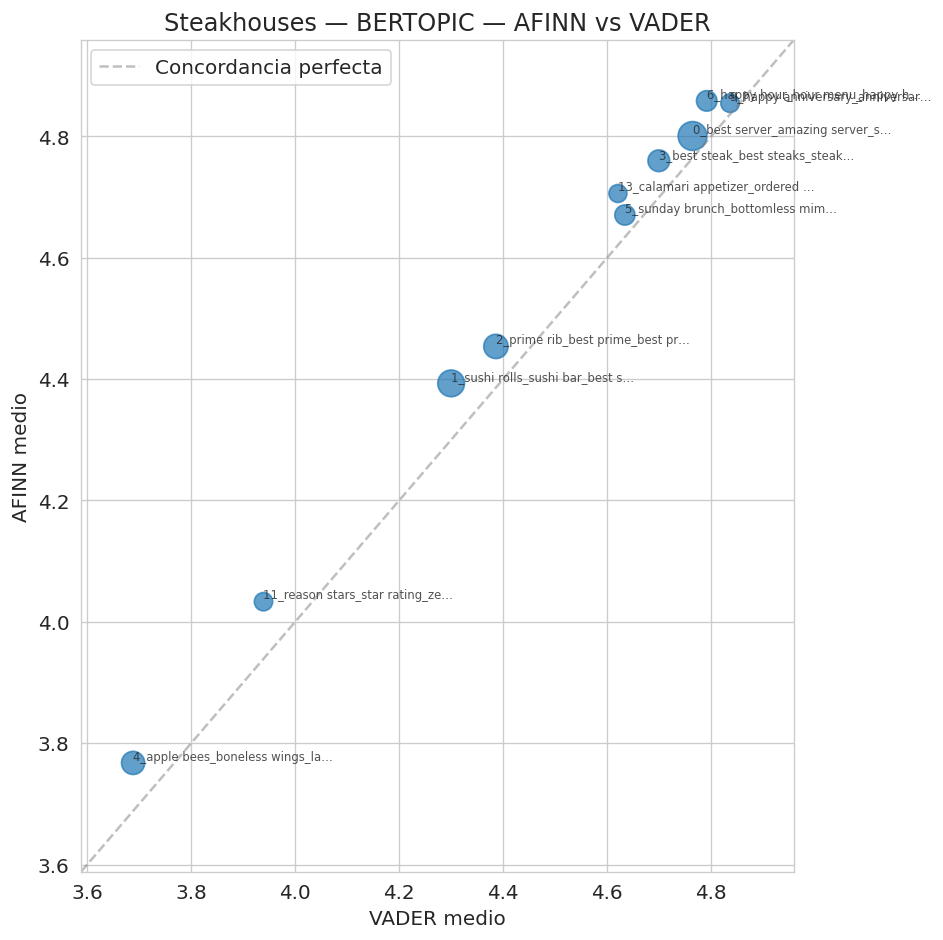

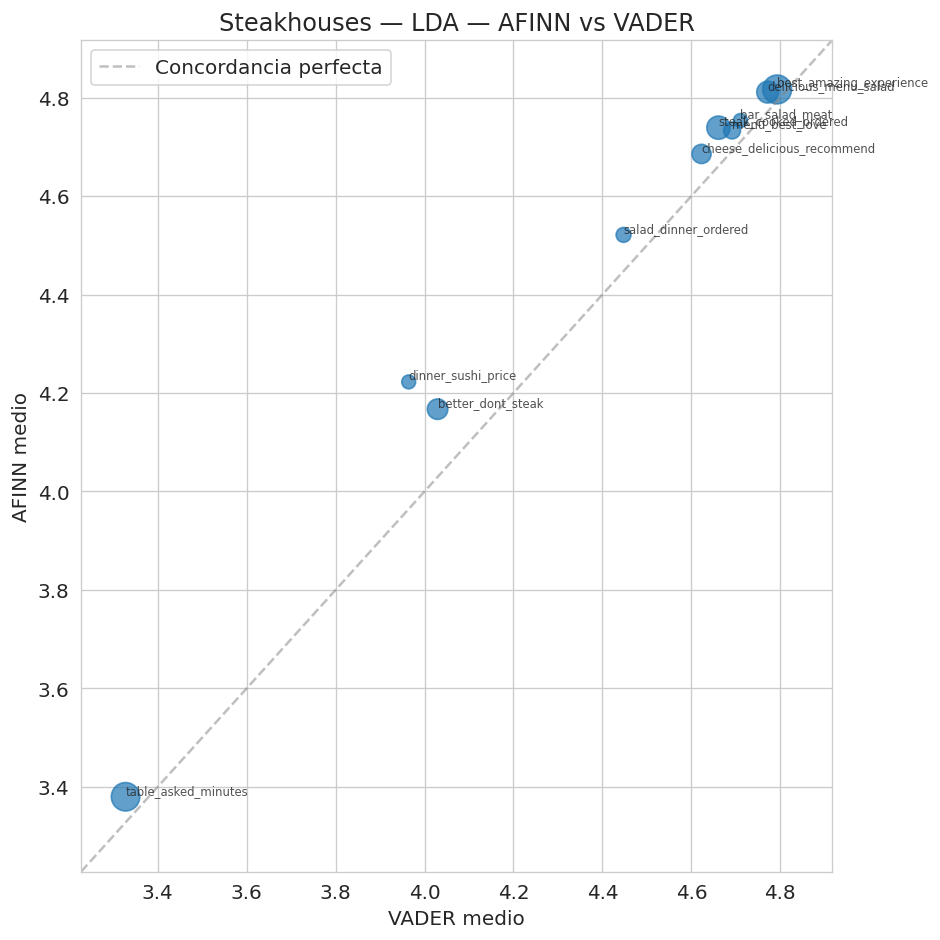


Top-5 tópicos más discordantes (AFINN vs VADER) por categoría y modelo
shape: (50, 6)
┌─────────────┬──────────┬─────────────────────────────────┬────────────┬────────────┬──────────┐
│ category    ┆ model    ┆ topic                           ┆ vader_mean ┆ afinn_mean ┆ abs_diff │
│ ---         ┆ ---      ┆ ---                             ┆ ---        ┆ ---        ┆ ---      │
│ str         ┆ str      ┆ str                             ┆ f64        ┆ f64        ┆ f64      │
╞═════════════╪══════════╪═════════════════════════════════╪════════════╪════════════╪══════════╡
│ burgers     ┆ bertopic ┆ 0_minutes later_drink order_10… ┆ 3.131      ┆ 3.01       ┆ 0.121    │
│ burgers     ┆ bertopic ┆ 4_biscuit love_east nasty_saus… ┆ 4.4186     ┆ 4.5158     ┆ 0.0972   │
│ burgers     ┆ bertopic ┆ 2_best wings_boneless wings_ho… ┆ 4.3507     ┆ 4.4303     ┆ 0.0796   │
│ burgers     ┆ bertopic ┆ 1_best pizza_style pizza_pizza… ┆ 4.2283     ┆ 4.2978     ┆ 0.0695   │
│ burgers     ┆ bertopic ┆ 7_bo

In [5]:
def plot_afinn_vs_vader(category_dfs, categories, topic_models, top_n=10):
    """
    Scatter plot: cada punto es un tópico (top-N).
    X = VADER medio, Y = AFINN medio.
    La diagonal indica concordancia perfecta.
    """
    discordance_rows = []

    for cat in categories:
        df = category_dfs[cat]
        for model_name, topic_col in topic_models.items():
            work_df = df
            if model_name == 'bertopic':
                work_df = df.filter(~pl.col(topic_col).str.starts_with('-1'))

            agg = (
                work_df.group_by(topic_col)
                .agg([
                    pl.col('vader_score').mean().alias('vader_mean'),
                    pl.col('afinn_score').mean().alias('afinn_mean'),
                    pl.col('review_id').count().alias('count'),
                ])
                .sort('count', descending=True)
                .head(top_n)
            ).to_pandas()

            agg['abs_diff'] = (agg['afinn_mean'] - agg['vader_mean']).abs()
            agg['label'] = agg[topic_col].apply(lambda x: x[:30] + '…' if len(str(x)) > 30 else str(x))

            top5 = agg.nlargest(5, 'abs_diff')
            for _, row in top5.iterrows():
                discordance_rows.append({
                    'category': cat, 'model': model_name,
                    'topic': row[topic_col],
                    'vader_mean': round(row['vader_mean'], 4),
                    'afinn_mean': round(row['afinn_mean'], 4),
                    'abs_diff': round(row['abs_diff'], 4),
                })

            fig, ax = plt.subplots(figsize=(8, 8))
            ax.scatter(agg['vader_mean'], agg['afinn_mean'], s=agg['count'] / agg['count'].max() * 300, alpha=0.7)

            for _, row in agg.iterrows():
                ax.annotate(row['label'], (row['vader_mean'], row['afinn_mean']),
                            fontsize=7, alpha=0.8, ha='left', va='bottom')

            lims = [min(agg['vader_mean'].min(), agg['afinn_mean'].min()) - 0.1,
                    max(agg['vader_mean'].max(), agg['afinn_mean'].max()) + 0.1]
            ax.plot(lims, lims, '--', color='gray', alpha=0.5, label='Concordancia perfecta')
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_xlabel('VADER medio')
            ax.set_ylabel('AFINN medio')
            ax.set_title(f'{cat.replace("_", " ").title()} — {model_name.upper()} — AFINN vs VADER')
            ax.legend()
            plt.tight_layout()
            plt.show()

    # Tabla resumen de discordancias
    if discordance_rows:
        disc_df = pl.DataFrame(discordance_rows)
        print('\nTop-5 tópicos más discordantes (AFINN vs VADER) por categoría y modelo')
        print(disc_df)


plot_afinn_vs_vader(category_dfs, categories, topic_models, top_n)

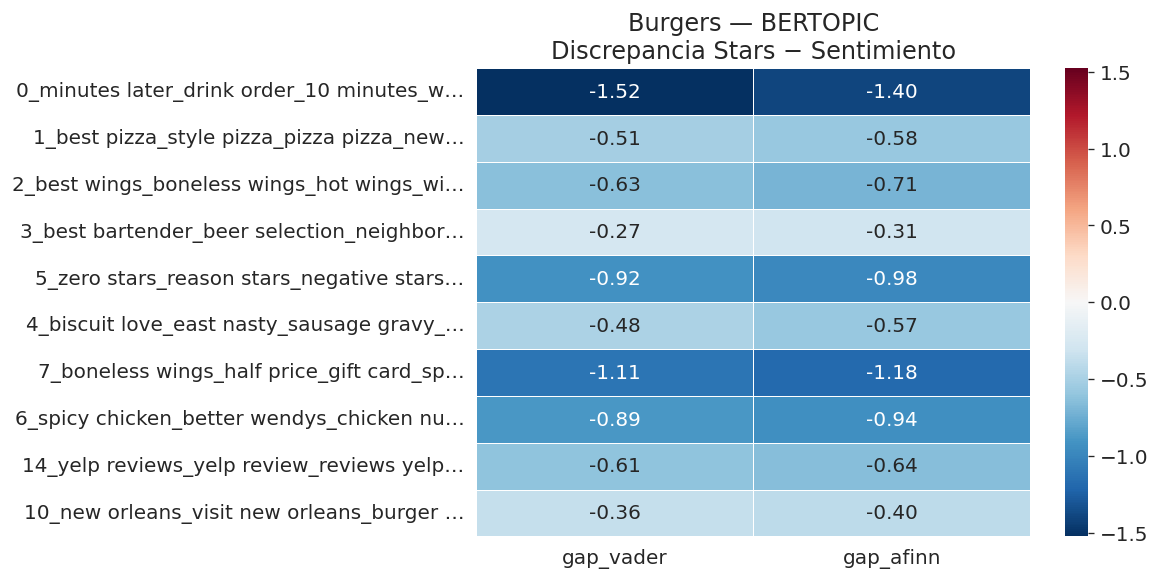

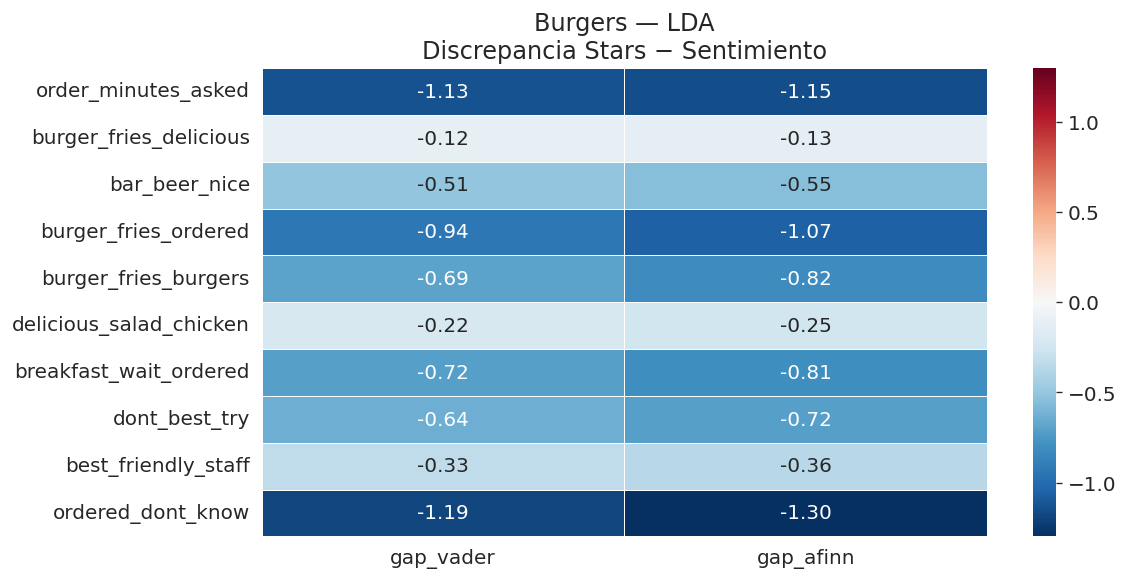

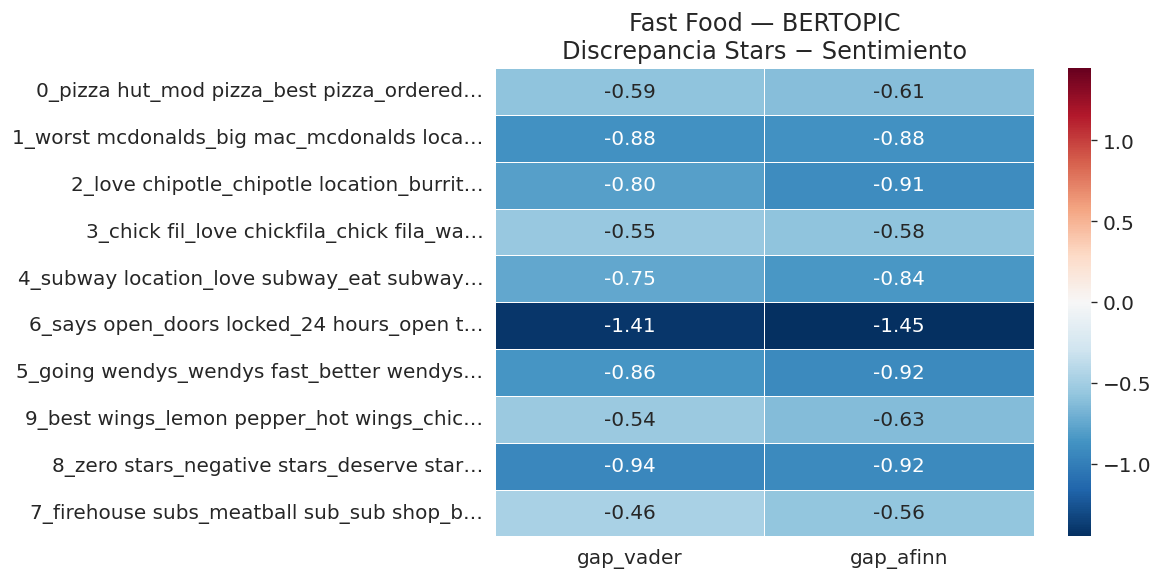

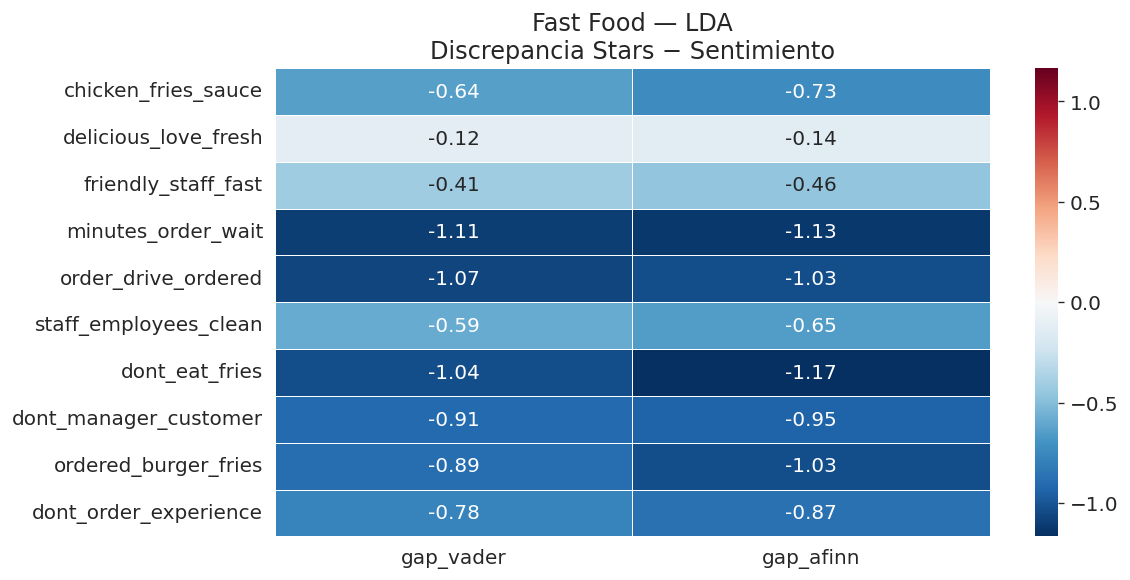

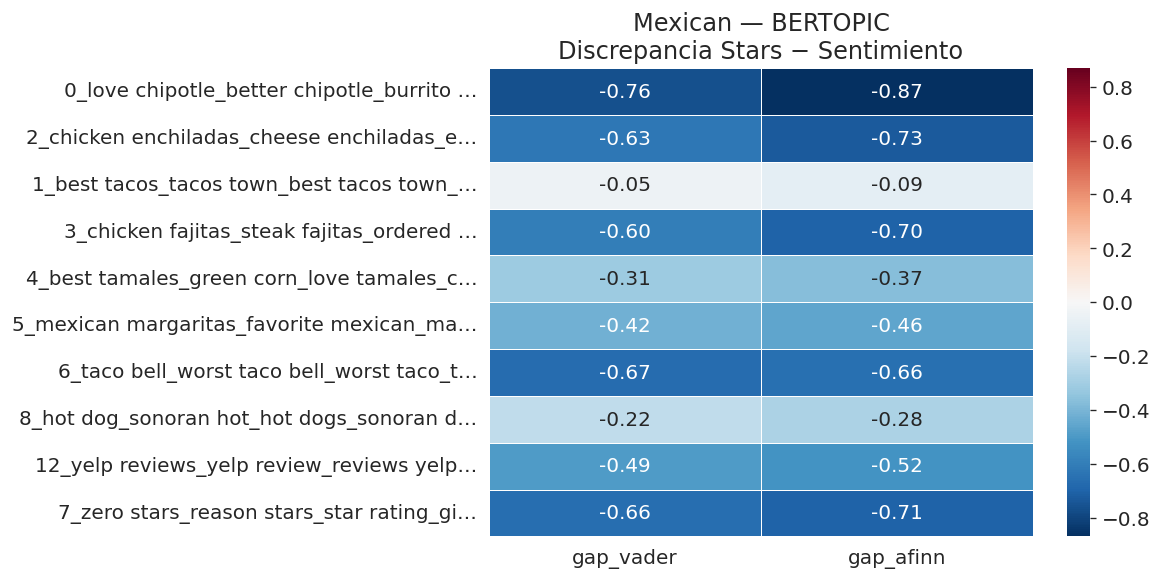

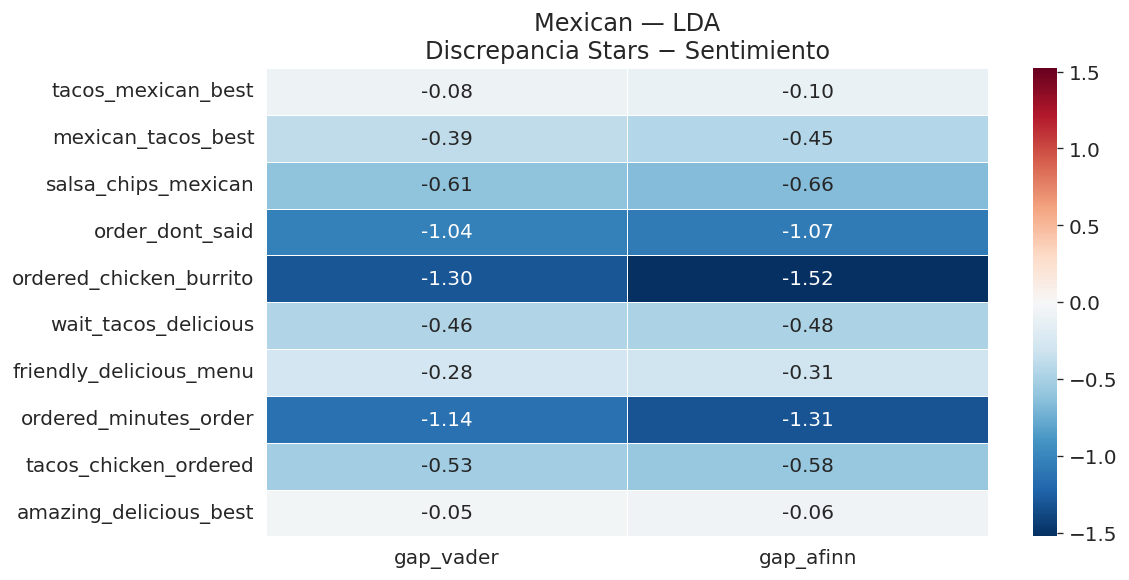

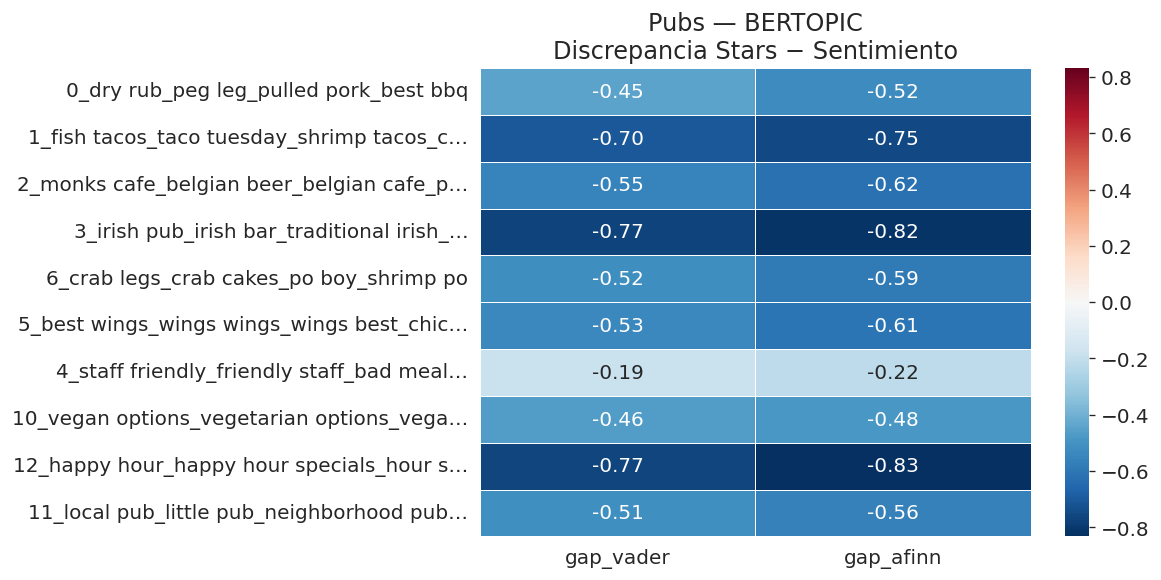

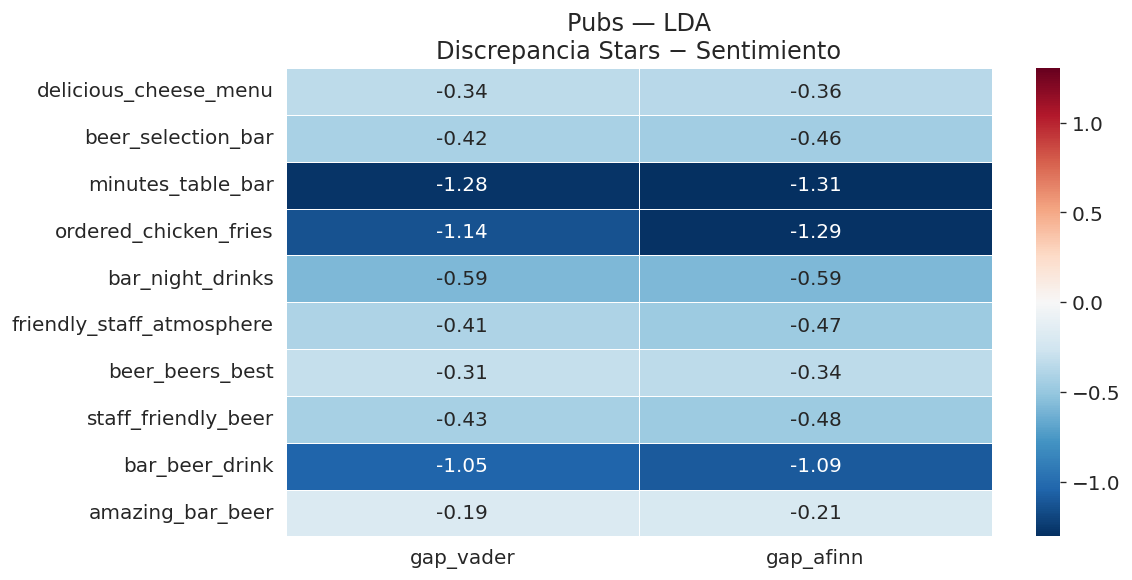

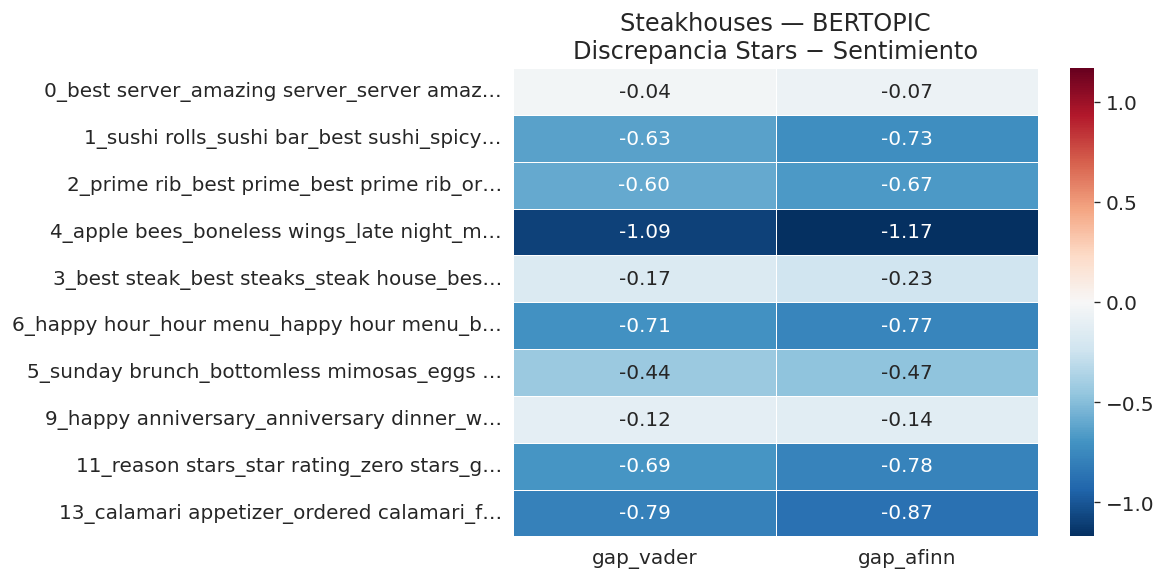

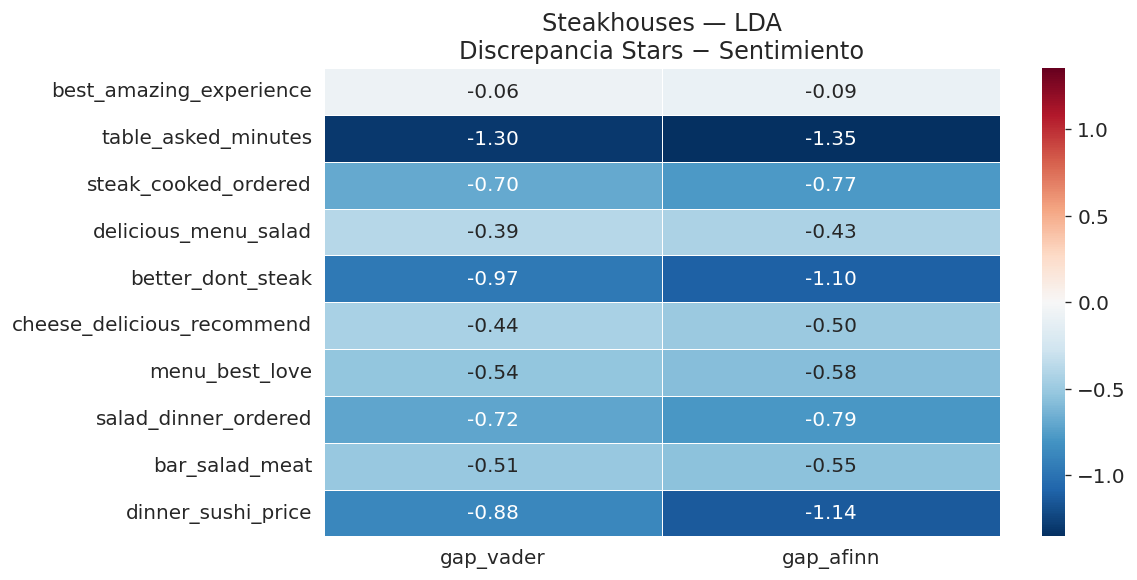

In [10]:
def plot_sentiment_stars_gap(category_dfs, categories, topic_models, top_n=10):
    """
    Heatmap de discrepancia: gap_vader = stars_mean − vader_mean,
                             gap_afinn = stars_mean − afinn_mean.
    Colores divergentes: rojo = sentimiento < estrellas, azul = sentimiento > estrellas.
    """
    for cat in categories:
        df = category_dfs[cat]
        for model_name, topic_col in topic_models.items():
            work_df = df
            if model_name == 'bertopic':
                work_df = df.filter(~pl.col(topic_col).str.starts_with('-1'))

            agg = (
                work_df.group_by(topic_col)
                .agg([
                    pl.col('stars').mean().alias('stars_mean'),
                    pl.col('vader_score').mean().alias('vader_mean'),
                    pl.col('afinn_score').mean().alias('afinn_mean'),
                    pl.col('review_id').count().alias('count'),
                ])
                .sort('count', descending=True)
                .head(top_n)
            ).to_pandas()

            agg['gap_vader'] = agg['stars_mean'] - agg['vader_mean']
            agg['gap_afinn'] = agg['stars_mean'] - agg['afinn_mean']
            agg['label'] = agg[topic_col].apply(lambda x: x[:40] + '…' if len(str(x)) > 40 else str(x))

            heatmap_data = agg.set_index('label')[['gap_vader', 'gap_afinn']]

            vmax = max(abs(heatmap_data.values.min()), abs(heatmap_data.values.max()), 0.5)

            fig, ax = plt.subplots(figsize=(10, max(4, len(agg) * 0.5)))
            sns.heatmap(
                heatmap_data, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-vmax, vmax=vmax, ax=ax,
                linewidths=0.5,
            )
            ax.set_title(f'{cat.replace("_", " ").title()} — {model_name.upper()}\nDiscrepancia Stars − Sentimiento')
            ax.set_ylabel('')
            plt.tight_layout()
            plt.show()


plot_sentiment_stars_gap(category_dfs, categories, topic_models, top_n)

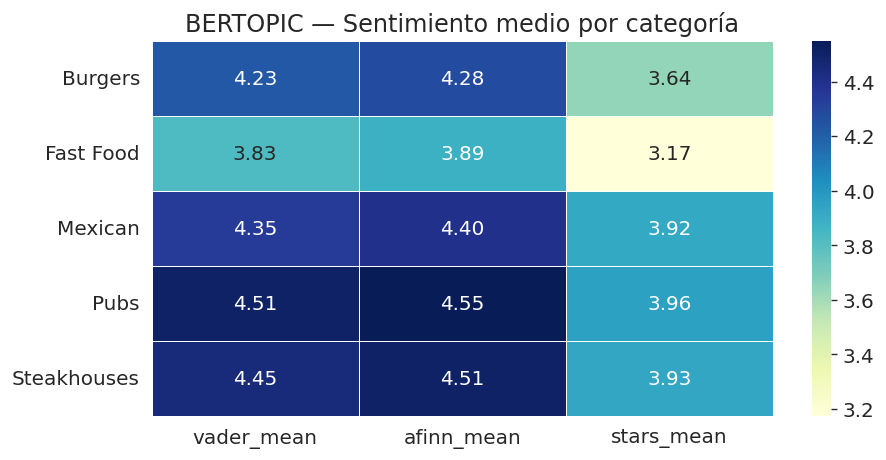

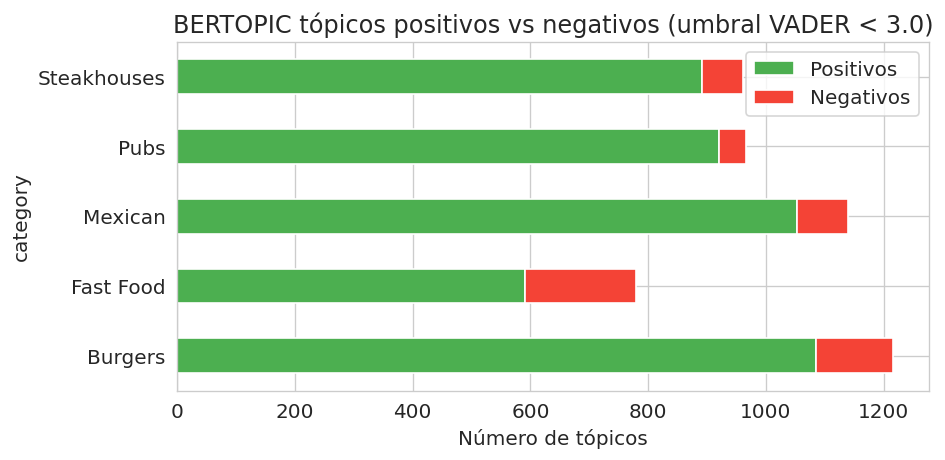

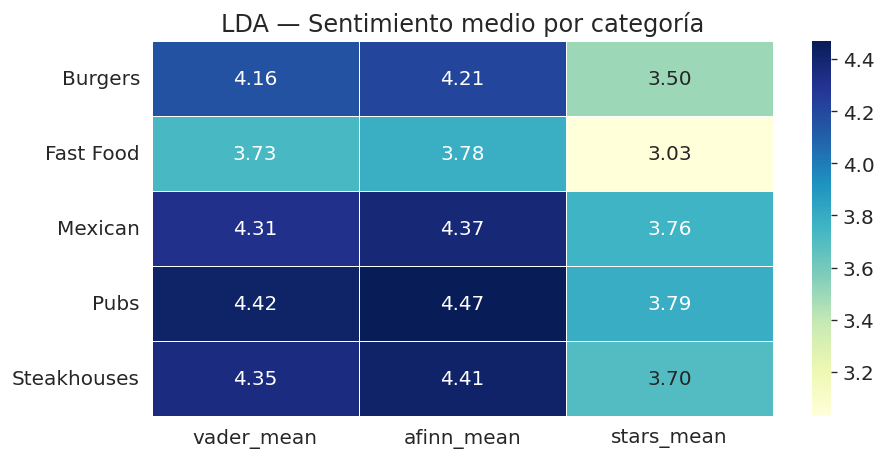

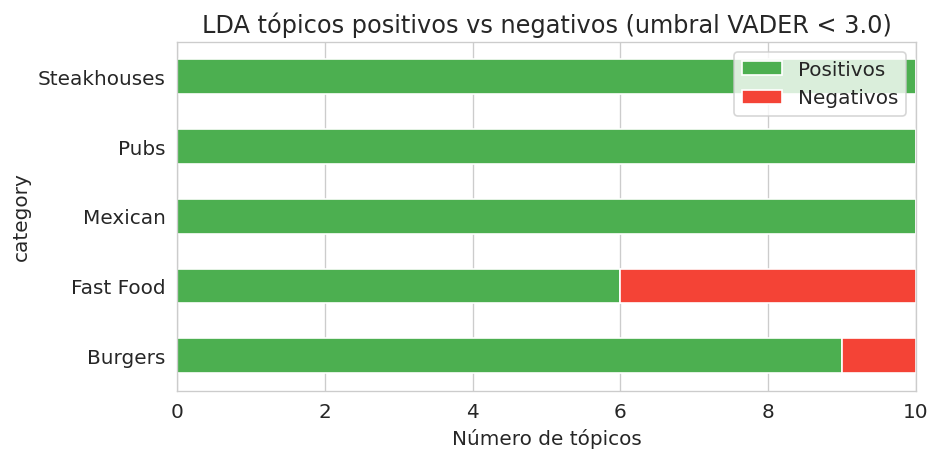

In [7]:
def plot_cross_category(category_dfs, categories, topic_models):
    """
    Heatmap global y bar chart apilado por categoría.
    """
    for model_name, topic_col in topic_models.items():
        rows = []
        for cat in categories:
            df = category_dfs[cat]
            work_df = df
            if model_name == 'bertopic':
                work_df = df.filter(~pl.col(topic_col).str.starts_with('-1'))

            cat_stats = (
                work_df.select([
                    pl.col('vader_score').mean().alias('vader_mean'),
                    pl.col('afinn_score').mean().alias('afinn_mean'),
                    pl.col('stars').mean().alias('stars_mean'),
                    pl.col('review_id').count().alias('count'),
                ])
                .to_dicts()[0]
            )
            cat_stats['category'] = cat.replace('_', ' ').title()
            rows.append(cat_stats)

        summary = pl.DataFrame(rows).to_pandas()

        hm = summary.set_index('category')[['vader_mean', 'afinn_mean', 'stars_mean']]
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.heatmap(hm, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, linewidths=0.5)
        ax.set_title(f'{model_name.upper()} — Sentimiento medio por categoría')
        ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

        neg_rows = []
        for cat in categories:
            df = category_dfs[cat]
            work_df = df
            if model_name == 'bertopic':
                work_df = df.filter(~pl.col(topic_col).str.starts_with('-1'))

            topic_means = (
                work_df.group_by(topic_col)
                .agg(pl.col('vader_score').mean().alias('vader_mean'))
            )
            n_total = topic_means.shape[0]
            n_neg = topic_means.filter(pl.col('vader_mean') < 3.0).shape[0]
            n_pos = n_total - n_neg
            neg_rows.append({
                'category': cat.replace('_', ' ').title(),
                'Positivos': n_pos,
                'Negativos': n_neg,
            })

        bar_df = pl.DataFrame(neg_rows).to_pandas().set_index('category')
        fig, ax = plt.subplots(figsize=(8, 4))
        bar_df.plot(kind='barh', stacked=True, ax=ax, color=['#4CAF50', '#F44336'])
        ax.set_xlabel('Número de tópicos')
        ax.set_title(f'{model_name.upper()} tópicos positivos vs negativos (umbral VADER < 3.0)')
        ax.legend()
        plt.tight_layout()
        plt.show()


plot_cross_category(category_dfs, categories, topic_models)